# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [2]:
# Import warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Import the libraries you will be using for analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.2.6
pandas version: 2.3.3
matplotlib version: 3.10.8
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [6]:
# Try loading one file
TRIP_RECORD_PATH = 'C:/Users/Rahul Jeyaraj/projects/APAGAI - Assignment - EDA/Starter Notebook - EDA NYC Taxi/trip_records/'
df = pd.read_parquet(TRIP_RECORD_PATH + '2023-1.parquet')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [ ]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
import os

# Select the folder having data files
os.chdir(TRIP_RECORD_PATH)

# Create a list of all the twelve files to read
file_list = os.listdir()

# initialise an empty dataframe
df = pd.DataFrame()


# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # file path for the current file
        file_path = os.path.join(os.getcwd(), file_name)

        # Reading the current file
        trip_record_df = pd.read_parquet(file_path)
        trip_record_df['date'] = trip_record_df['tpep_pickup_datetime'].dt.date
        trip_record_df['hour'] = trip_record_df['tpep_pickup_datetime'].dt.hour

        # We will store the sampled data for the current date in this df by appending the sampled data from each hour to this
        # After completing iteration through each date, we will append this data to the final dataframe.
        sampled_data = pd.DataFrame()

        # Loop through dates and then loop through every hour of each date
        for date in trip_record_df['date'].unique():
            df_date = trip_record_df[trip_record_df['date'] == date]

            # Iterate through each hour of the selected date
            for hour in range(24):
                df_hour = df_date[df_date['hour'] == hour]
                if len(df_hour) == 0:
                    continue

                # Sample 5% of the hourly data randomly
                sample = df_hour.sample(frac = 0.05, random_state = 42)

                # add data of this hour to the dataframe
                sampled_data = pd.concat([sampled_data, sample])

        # Drop temporary columns
        sampled_data = sampled_data.drop(columns=['date', 'hour'])

        # Concatenate the sampled data of all the dates to a single dataframe
        df = pd.concat([df, sampled_data])
        print(f"  Sampled: {len(sampled_data):,} rows | Total so far: {len(df):,}")

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

  Sampled: 152,087 rows | Total so far: 152,087
  Sampled: 174,255 rows | Total so far: 326,342
  Sampled: 165,133 rows | Total so far: 491,475
  Sampled: 166,709 rows | Total so far: 658,184
  Sampled: 168,696 rows | Total so far: 826,880
  Sampled: 163,786 rows | Total so far: 990,666
  Sampled: 139,641 rows | Total so far: 1,130,307
  Sampled: 144,458 rows | Total so far: 1,274,765
  Sampled: 162,910 rows | Total so far: 1,437,675
  Sampled: 174,068 rows | Total so far: 1,611,743
  Sampled: 143,782 rows | Total so far: 1,755,525
  Sampled: 140,875 rows | Total so far: 1,896,400
  Sampled: 99,662 rows | Total so far: 1,996,062
  Sampled: 94,927 rows | Total so far: 2,090,989


After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [ ]:
# Store the df in csv/parquet
df.to_parquet(TRIP_RECORD_PATH + 'nyc_taxi_sampled_2023.parquet', index=False)
print(f"Saved sampled data: {len(df):,} rows")

Saved sampled data: 2,090,989 rows


## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [7]:
# Load the new data file
df = pd.read_parquet(TRIP_RECORD_PATH + 'nyc_taxi_sampled_2023.parquet')


In [8]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee
0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,32.40,6.0,0.5,0.00,0.0,1.0,41.15,0.0,1.25,NaN
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,7.90,1.0,0.5,2.58,0.0,1.0,15.48,2.5,0.00,NaN
2,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,11.40,1.0,0.5,0.00,0.0,1.0,16.40,2.5,0.00,NaN
3,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,6.50,1.0,0.5,0.00,0.0,1.0,11.50,2.5,0.00,NaN
4,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,None,66,107,0,25.64,0.0,0.5,5.93,0.0,1.0,35.57,NaN,NaN,NaN


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2090989 entries, 0 to 2090988
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee           

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [10]:
# Fix the index and drop any columns that are not needed
# Reset index to ensure clean sequential indexing
df = df.reset_index(drop=True)

# Drop 'store_and_fwd_flag' as it is not useful for our analysis
df = df.drop(columns=['store_and_fwd_flag'], errors='ignore')

print(f"Shape after dropping unnecessary columns: {df.shape}")
df.head()


Shape after dropping unnecessary columns: (2090989, 19)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee
0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,138,256,2,32.40,6.0,0.5,0.00,0.0,1.0,41.15,0.0,1.25,NaN
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,161,237,1,7.90,1.0,0.5,2.58,0.0,1.0,15.48,2.5,0.00,NaN
2,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,237,141,2,11.40,1.0,0.5,0.00,0.0,1.0,16.40,2.5,0.00,NaN
3,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,143,142,2,6.50,1.0,0.5,0.00,0.0,1.0,11.50,2.5,0.00,NaN
4,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,66,107,0,25.64,0.0,0.5,5.93,0.0,1.0,35.57,NaN,NaN,NaN


**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [11]:
# Combine the two airport fee columns
# Fill NaN with 0 and combine them by taking the sum (since one should be 0 or NaN)
df['airport_fee'] = df['airport_fee'].fillna(0) + df['Airport_fee'].fillna(0)
df = df.drop(columns=['Airport_fee'])
print(f"\nairport_fee value counts:\n{df['airport_fee'].value_counts()}")


airport_fee value counts:
airport_fee
 0.00    1913614
 1.75     133604
 1.25      43753
-1.75         13
-1.25          4
 1.00          1
Name: count, dtype: int64


**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [12]:
# check where values of fare amount are negative
negative_fares = df[df['fare_amount'] < 0]
print(f"Number of records with negative fare_amount: {len(negative_fares)}")

Number of records with negative fare_amount: 0


Did you notice something different in the `RatecodeID` column for above records?

In [13]:
# Analyse RatecodeID for the negative fare amounts
if len(negative_fares) > 0:
    print("RatecodeID distribution for negative fare records:")
    print(negative_fares['RatecodeID'].value_counts())
else:
    print("No negative fare_amount records found in our sampled data.")
    print("This is expected — sampling 5% randomly may have excluded such rare anomalies.")
    print("\nFor reference, overall RatecodeID distribution:")
    print(df['RatecodeID'].value_counts())
    print("\nNote: RatecodeID = 99 is undefined per data dictionary — flagged for outlier handling")

No negative fare_amount records found in our sampled data.
This is expected — sampling 5% randomly may have excluded such rare anomalies.

For reference, overall RatecodeID distribution:
RatecodeID
1.0     1906637
2.0       79042
99.0      11522
5.0       11351
3.0        6736
4.0        4108
6.0           3
Name: count, dtype: int64

Note: RatecodeID = 99 is undefined per data dictionary — flagged for outlier handling


In [14]:
# Find which columns have negative values
numeric_cols = df.select_dtypes(include=[np.number]).columns
print("\nColumns with negative values:")
for col in numeric_cols:
    neg_count = (df[col] < 0).sum()
    if neg_count > 0:
        print(f"{col}: {neg_count}")


Columns with negative values:
extra: 3
mta_tax: 86
improvement_surcharge: 91
total_amount: 91
congestion_surcharge: 65
airport_fee: 17


In [15]:
# fix these negative values
for col in numeric_cols:
    neg_count = (df[col] < 0).sum()
    if neg_count > 0:
        df[col] = df[col].abs()
        print(f"Fixed {neg_count} negative values in '{col}'")


Fixed 3 negative values in 'extra'
Fixed 86 negative values in 'mta_tax'
Fixed 91 negative values in 'improvement_surcharge'
Fixed 91 negative values in 'total_amount'
Fixed 65 negative values in 'congestion_surcharge'
Fixed 17 negative values in 'airport_fee'


### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [16]:
# Find the proportion of missing values in each column
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print("Columns with missing values:\n")
print(missing_df.to_string())
print(f"\nTotal rows: {len(df):,}")


Columns with missing values:

                      Missing Count  Missing %
passenger_count               71590   3.423739
RatecodeID                    71590   3.423739
congestion_surcharge          71590   3.423739

Total rows: 2,090,989


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [17]:
# Display the rows with null values
# Impute NaN values in 'passenger_count'
print(f"Null values in 'passenger_count': {df['passenger_count'].isnull().sum()}")
print(f"Zero values in 'passenger_count': {(df['passenger_count'] == 0).sum()}")

# Impute NaN values in 'passenger_count' with mode
mode_passenger_count = df['passenger_count'].mode()[0]
print(f"Mode of 'passenger_count': {mode_passenger_count}")
df['passenger_count'] = df['passenger_count'].fillna(mode_passenger_count)

# Handle any zero values in 'passenger_count' (assuming 0 passengers is not valid for a taxi trip)
df.loc[df['passenger_count'] == 0, 'passenger_count'] = mode_passenger_count

print(f"\nAfter imputation:")
print(f"\tNull values in 'passenger_count': {df['passenger_count'].isnull().sum()}")
print(f"\tZero values in 'passenger_count': {(df['passenger_count'] == 0).sum()}")
print(f"\nPassenger_count distribution:")
print(df['passenger_count'].value_counts().sort_index())

Null values in 'passenger_count': 71590
Zero values in 'passenger_count': 32791
Mode of 'passenger_count': 1.0

After imputation:
	Null values in 'passenger_count': 0
	Zero values in 'passenger_count': 0

Passenger_count distribution:
passenger_count
1.0    1623288
2.0     305678
3.0      75866
4.0      42430
5.0      26195
6.0      17510
7.0          5
8.0         12
9.0          5
Name: count, dtype: int64


Did you find zeroes in passenger_count? Handle these.

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [18]:
# Fix missing values in 'RatecodeID'
print(f"Null values in RatecodeID: {df['RatecodeID'].isnull().sum()}")
print(f"RatecodeID value counts before fix:")
print(df['RatecodeID'].value_counts().sort_index())

# Replace RatecodeID = 99 with NaN (these are error codes), then fill with mode
df.loc[df['RatecodeID'] == 99, 'RatecodeID'] = np.nan

mode_ratecodeid = df['RatecodeID'].mode()[0]
df['RatecodeID'] = df['RatecodeID'].fillna(mode_ratecodeid)

print(f"\n RatecodeID value counts after fix:")
print(df['RatecodeID'].value_counts().sort_index())

Null values in RatecodeID: 71590
RatecodeID value counts before fix:
RatecodeID
1.0     1906637
2.0       79042
3.0        6736
4.0        4108
5.0       11351
6.0           3
99.0      11522
Name: count, dtype: int64

 RatecodeID value counts after fix:
RatecodeID
1.0    1989749
2.0      79042
3.0       6736
4.0       4108
5.0      11351
6.0          3
Name: count, dtype: int64


**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [19]:
# handle null values in congestion_surcharge
print(f"Null values in congestion_surcharge: {df['congestion_surcharge'].isnull().sum()}")
print(f"Congestion surcharge value counts before fix:")
print(df['congestion_surcharge'].value_counts().sort_index())

# Impute NaN values in 'congestion_surcharge' with 0 (assuming no surcharge if not specified)
df['congestion_surcharge'] = df['congestion_surcharge'].fillna(0)

print(f"\nCongestion surcharge value counts after fix:")
print(df['congestion_surcharge'].value_counts().sort_index())


Null values in congestion_surcharge: 71590
Congestion surcharge value counts before fix:
congestion_surcharge
0.0     155211
0.5          1
2.5    1864187
Name: count, dtype: int64

Congestion surcharge value counts after fix:
congestion_surcharge
0.0     226801
0.5          1
2.5    1864187
Name: count, dtype: int64


Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [20]:
# Handle any remaining missing values
remaining_missing = df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]

if len(remaining_missing) > 0:
    print("\nRemaining columns with missing values:")
    print(remaining_missing)

    #Fill remaining missing values with 0 (assuming missing means no charge for these columns)
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in remaining_missing.index:
        if col in numeric_cols:
            df[col] = df[col].fillna(0)
            print(f"Filled missing values in '{col}' with 0")
else:
    print("\nNo remaining missing values.")

# Final check for missing values
print("\nFinal check for missing values:")
print(df.isnull().sum())


No remaining missing values.

Final check for missing values:
VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
airport_fee              0
dtype: int64


### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [21]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns

# All numeric columns
all_numeric = df.select_dtypes(include='number').columns.tolist()

# Then exclude the ones that are actually categorical
categorical_numeric = ['VendorID', 'RatecodeID', 'PULocationID', 
                       'DOLocationID', 'payment_type']
desc_cols = [c for c in all_numeric if c not in categorical_numeric]

print("Statistical Summary of Key Columns:\n")
print(df[desc_cols].describe().round(2).to_string())

print("\nPotential Outlier Indicators:\n")
print(f"trip_distance: max = {df['trip_distance'].max():.2f} miles")
print(f"fare_amount: max = ${df['fare_amount'].max():.2f}")
print(f"tip_amount: max = ${df['tip_amount'].max():.2f}")
print(f"tolls_amount: max = ${df['tolls_amount'].max():.2f}")
print(f"total_amount: max = ${df['total_amount'].max():.2f}")
print(f"passenger_count: max = {df['passenger_count'].max()}")
print(f"\ntrip_distance == 0: {(df['trip_distance'] == 0).sum()} trips")
print(f"fare_amount == 0: {(df['fare_amount'] == 0).sum()} trips")

Statistical Summary of Key Columns:

       passenger_count  trip_distance  fare_amount       extra     mta_tax  tip_amount  tolls_amount  improvement_surcharge  total_amount  congestion_surcharge  airport_fee
count       2090989.00     2090989.00   2090989.00  2090989.00  2090989.00  2090989.00    2090989.00             2090989.00    2090989.00            2090989.00   2090989.00
mean              1.37           3.86        19.91        1.59        0.50        3.55          0.60                   1.00         28.97                  2.23         0.14
std               0.86         126.83       100.66        1.83        0.05        4.06          2.19                   0.03        101.58                  0.78         0.46
min               1.00           0.00         0.00        0.00        0.00        0.00          0.00                   0.00          0.00                  0.00         0.00
25%               1.00           1.05         9.30        0.00        0.50        1.00          0.

**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [22]:
# remove passenger_count > 6
print(f"\nRecords with passenger_count > 6: {(df['passenger_count'] > 6).sum()}")
print(f"Shape before: {df.shape}")
df = df[df['passenger_count'] <= 6]
df = df.reset_index(drop=True)
print(f"Shape after: {df.shape}")


Records with passenger_count > 6: 22
Shape before: (2090989, 18)
Shape after: (2090967, 18)


In [23]:
# Continue with outlier handling
print(f"Shape before outlier removal: {df.shape}")

# Trip_distance nearly 0 but fare_amount > 300 (error entries)
mask = (df['trip_distance'] < 0.1) & (df['fare_amount'] > 300)
print(f"trip_distance~0 but fare>300: {mask.sum()}")
df = df[~mask]

# Both trip_distance AND fare_amount are 0 but zones are different (trip didn't happen)
mask = (df['trip_distance'] == 0) & (df['fare_amount'] == 0) & (df['PULocationID'] != df['DOLocationID'])
print(f"distance=0, fare=0, different zones: {mask.sum()}")
df = df[~mask]

# trip_distance > 250 miles (unrealistic for NYC taxi)
mask = df['trip_distance'] > 250
print(f"trip_distance > 250 miles: {mask.sum()}")
df = df[~mask]

# Payment_type = 0 (undefined in data dictionary)
mask = df['payment_type'] == 0
print(f"payment_type = 0: {mask.sum()}")
df = df[~mask]

# Fare_amount > 300 
mask = df['fare_amount'] > 300
print(f"fare_amount > 300: {mask.sum()}")
df = df[~mask]

# Total_amount > 300 (consistent with fare_amount cap)
mask = df['total_amount'] > 300
print(f"total_amount > 300: {mask.sum()}")
df = df[~mask]

# Drop zero fare trips where payment was Cash or Credit card (should have a fare)
mask = (df['fare_amount'] == 0) & (df['payment_type'].isin([1, 2]))
print(f"Zero fare with Cash/Credit payment: {mask.sum()}")
df = df[~mask]

# Create trip duration column
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60
mask = (df['trip_duration'] <= 0) | (df['trip_duration'] > 180)
print(f"Trips with duration <= 0 min: {(df['trip_duration'] <= 0).sum()}")
print(f"Trips with duration > 180 min: {(df['trip_duration'] > 180).sum()}")
print(f"Total removed by duration filter: {mask.sum()}")
df = df[~mask]

# Filter trips within 2023 only
mask = (df['tpep_pickup_datetime'].dt.year != 2023) | (df['tpep_dropoff_datetime'].dt.year != 2023)
print(f"Trips outside 2023: {mask.sum()}")
df = df[~mask]

df = df.reset_index(drop=True)
print(f"\nShape after outlier removal: {df.shape}")



Shape before outlier removal: (2090967, 18)
trip_distance~0 but fare>300: 36
distance=0, fare=0, different zones: 69
trip_distance > 250 miles: 50
payment_type = 0: 71556
fare_amount > 300: 143
total_amount > 300: 144
Zero fare with Cash/Credit payment: 385
Trips with duration <= 0 min: 755
Trips with duration > 180 min: 1868
Total removed by duration filter: 2623
Trips outside 2023: 24

Shape after outlier removal: (2015937, 19)


In [24]:
# Do any columns need standardising?

df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month
df['pickup_month_name'] = df['tpep_pickup_datetime'].dt.month_name()
df['pickup_dayofweek'] = df['tpep_pickup_datetime'].dt.dayofweek
df['is_weekend'] = df['pickup_dayofweek'].isin([5, 6]).astype(bool)

#Ensure integer types for ID columns
for col in ['VendorID', 'RatecodeID', 'PULocationID', 'DOLocationID', 'payment_type']:
    if col in df.columns:
        df[col] = df[col].astype(int)

df['passenger_count'] = df['passenger_count'].astype(int)

print("Derived columns added: pickup_hour, pickup_day, pickup_month, pickup_month_name, pickup_dayofweek, is_weekend")
print(f"\nDataFrame shape: {df.shape}")
print(f"\nColumn dtypes:")
print(df.dtypes)


Derived columns added: pickup_hour, pickup_day, pickup_month, pickup_month_name, pickup_dayofweek, is_weekend

DataFrame shape: (2015937, 25)

Column dtypes:
VendorID                          int64
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                   int64
trip_distance                   float64
RatecodeID                        int64
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
airport_fee                     float64
trip_duration                   float64
pickup_hour                       int32
pickup_day                       object
pi

## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [25]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee',
 'trip_duration',
 'pickup_hour',
 'pickup_day',
 'pickup_month',
 'pickup_month_name',
 'pickup_dayofweek',
 'is_weekend']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`: Categorical (nominal) — just a label for the vendor, 1 or 2
* `tpep_pickup_datetime`: Categorical (temporal) — a timestamp, not a quantity
* `tpep_dropoff_datetime`: Categorical (temporal) — a timestamp, not a quantity
* `passenger_count`: Numerical (discrete) — countable whole numbers
* `trip_distance`: Numerical (continuous) — measurable, can have decimals
* `RatecodeID`: Categorical (nominal) — codes representing rate types, not quantities
* `PULocationID`: Categorical (nominal) — zone codes, not quantities
* `DOLocationID`: Categorical (nominal) — zone codes, not quantities
* `payment_type`: Categorical (nominal) — codes representing payment method
* `pickup_hour`: Categorical (ordinal) — 0-23, has order but not a true quantity
* `trip_duration`: Numerical (continuous) — measured in minutes, can have decimals


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

These are all measured quantities in USD that can take any decimal value — 
making them **continuous numerical variables**.

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

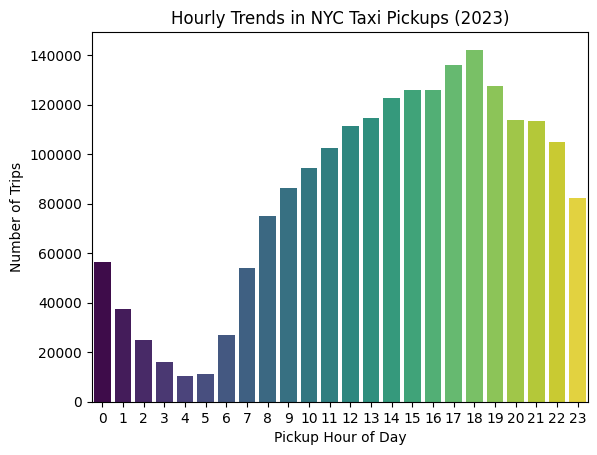

In [26]:
# Find and show the hourly trends in taxi pickups
hourly_pickups = df.groupby('pickup_hour').size().reset_index(name='num_trips')

sns.barplot(x='pickup_hour', y='num_trips', data=hourly_pickups, 
            palette='viridis', hue='pickup_hour', legend=False)
plt.title('Hourly Trends in NYC Taxi Pickups (2023)')
plt.xlabel('Pickup Hour of Day')
plt.ylabel('Number of Trips')
plt.xticks(range(0, 24))
plt.show()

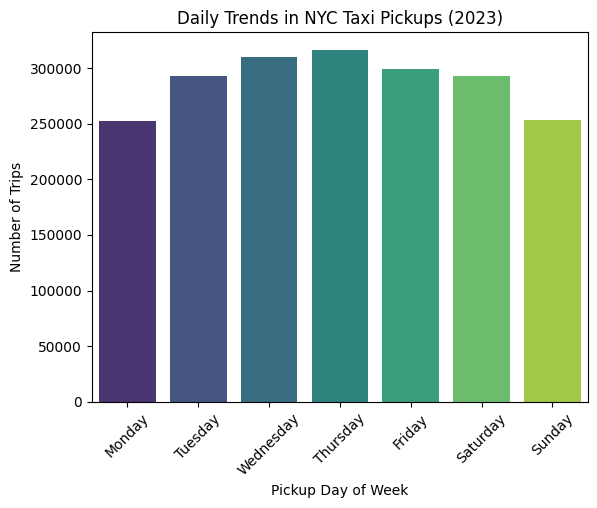

In [27]:
# Find and show the daily trends in taxi pickups (days of the week)
daily_pickups = df.groupby('pickup_day').size().reset_index(name='num_trips')

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_pickups['pickup_day'] = pd.Categorical(daily_pickups['pickup_day'], categories=day_order, ordered=True)
daily_pickups = daily_pickups.sort_values('pickup_day')

sns.barplot(x='pickup_day', y='num_trips', data=daily_pickups,
            palette='viridis', hue='pickup_day', legend=False)
plt.title('Daily Trends in NYC Taxi Pickups (2023)')
plt.xlabel('Pickup Day of Week')
plt.ylabel('Number of Trips')
plt.xticks(rotation=45)
plt.show()


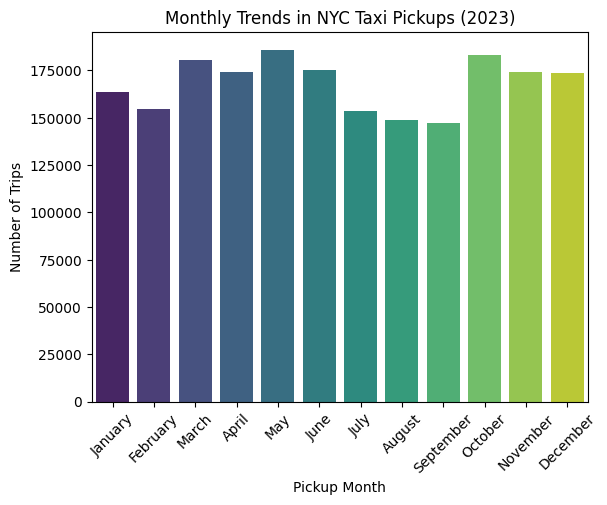

In [28]:
# Show the monthly trends in pickups
monthly_pickups = df.groupby('pickup_month_name').size().reset_index(name='num_trips')
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_pickups['pickup_month_name'] = pd.Categorical(monthly_pickups['pickup_month_name'], categories=month_order, ordered=True)
monthly_pickups = monthly_pickups.sort_values('pickup_month_name')

sns.barplot(x='pickup_month_name', y='num_trips', data=monthly_pickups,
            palette='viridis', hue='pickup_month_name', legend=False)
plt.title('Monthly Trends in NYC Taxi Pickups (2023)')
plt.xlabel('Pickup Month')
plt.ylabel('Number of Trips')
plt.xticks(rotation=45)
plt.show()

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [29]:
# Analyse the above parameters
financial_cols = ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']

print("Summary statistics for financial and distance parameters:\n")
print(df[financial_cols].describe().round(2).to_string())

print("\nZero/Negative values in financial and distance parameters:")
for col in financial_cols:
    zero_count = (df[col] == 0).sum()
    neg_count = (df[col] < 0).sum()
    print(f"{col}\t: {zero_count} zero values, \t{neg_count} negative values")


Summary statistics for financial and distance parameters:

       fare_amount  tip_amount  total_amount  trip_distance
count   2015937.00  2015937.00    2015937.00     2015937.00
mean         19.69        3.57         28.81           3.44
std          17.81        4.04         22.45           4.49
min           0.00        0.00          0.00           0.00
25%           9.30        1.00         15.96           1.05
50%          13.50        2.86         21.00           1.78
75%          21.90        4.45         30.70           3.37
max         299.00      223.08        300.00         187.35

Zero/Negative values in financial and distance parameters:
fare_amount	: 248 zero values, 	0 negative values
tip_amount	: 450445 zero values, 	0 negative values
total_amount	: 136 zero values, 	0 negative values
trip_distance	: 24311 zero values, 	0 negative values


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?


> Original df can be kept for general analysis (trip counts, temporal trends etc.)
> Copy df can be used specifically for financial and distance analysis
>
> If you drop from original:
> - trip counts become wrong
> - hourly/daily trends become inaccurate
> - passenger count analysis loses data
>
> If you use a copy:
> - original df stays intact for non-financial analysis
> - copy df gives accurate financial/distance insights


**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

> No, zero distance trips should not be dropped entirely.
>
> - Pickup and dropoff in the same zone can still be a valid short trip with a legitimate fare
> - We already removed the truly invalid ones in 2.3.1 (distance=0, fare=0, different zones)
> - Remaining zero distance trips are excluded only when distance is directly relevant — using `df_nz`
> - For general analysis like trip counts and revenue, they are kept in `df`


In [30]:
# Create a df with non zero entries for the selected parameters.
df_nz = df[(df['fare_amount'] > 0) & (df['tip_amount'] > 0) &
            (df['total_amount'] > 0) & (df['trip_distance'] > 0)].copy()

print(f"Original df shape: {df.shape}")
print(f"Non-zero df shape: {df_nz.shape}")
print(f"Number of rows removed: {df.shape[0] - df_nz.shape[0]}")
print(f"Number of rows removed percentage: {(df.shape[0] - df_nz.shape[0]) / df.shape[0] * 100:.2f}%")

Original df shape: (2015937, 25)
Non-zero df shape: (1556458, 25)
Number of rows removed: 459479
Number of rows removed percentage: 22.79%


**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

pickup_month_name  total_amount
          January    4455501.23
         February    4215183.07
            March    5072981.25
            April    4993095.89
              May    5435270.92
             June    5115019.45
             July    4444281.30
           August    4337157.53
        September    4424144.57
          October    5450346.86
         November    5073777.19
         December    5061105.47

Highest revenue month: October
Lowest revenue month:  February


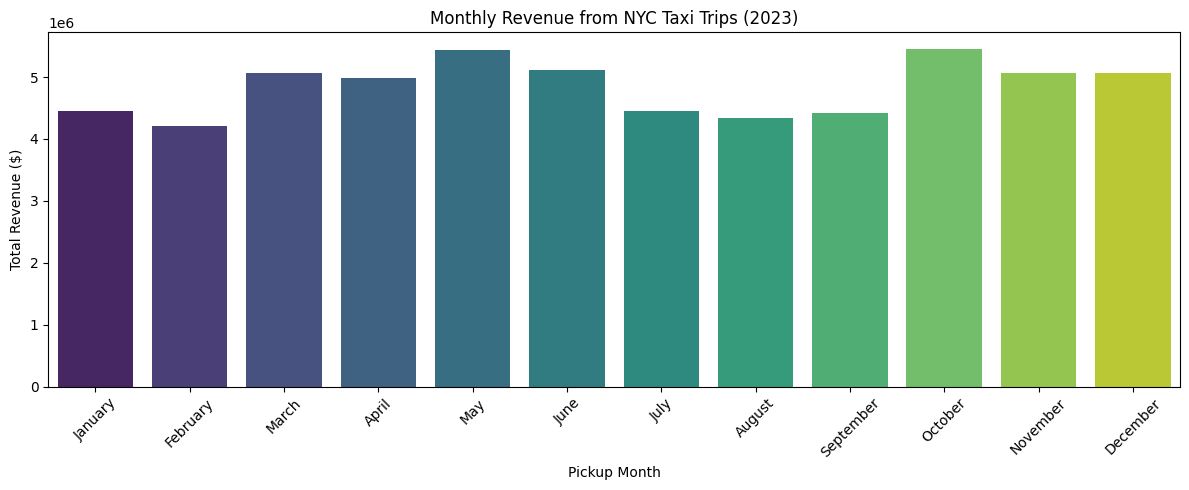

In [31]:
# Group data by month and analyse monthly revenue
monthly_revenue = df.groupby('pickup_month_name')['total_amount'].sum().reset_index()

# Order months correctly
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_revenue['pickup_month_name'] = pd.Categorical(monthly_revenue['pickup_month_name'], 
                                                       categories=month_order, ordered=True)
monthly_revenue = monthly_revenue.sort_values('pickup_month_name')

# Print summary before plotting
print(monthly_revenue.to_string(index=False))
print(f"\nHighest revenue month: {monthly_revenue.loc[monthly_revenue['total_amount'].idxmax(), 'pickup_month_name']}")
print(f"Lowest revenue month:  {monthly_revenue.loc[monthly_revenue['total_amount'].idxmin(), 'pickup_month_name']}")

plt.figure(figsize=(12, 5))
sns.barplot(x='pickup_month_name', y='total_amount', data=monthly_revenue,
            palette='viridis', hue='pickup_month_name', legend=False)
plt.title('Monthly Revenue from NYC Taxi Trips (2023)')
plt.xlabel('Pickup Month')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

quarter_label  total_amount  proportion
           Q1   13743665.55   23.664206
           Q2   15543386.26   26.763013
           Q3   13205583.40   22.737722
           Q4   15585229.52   26.835059


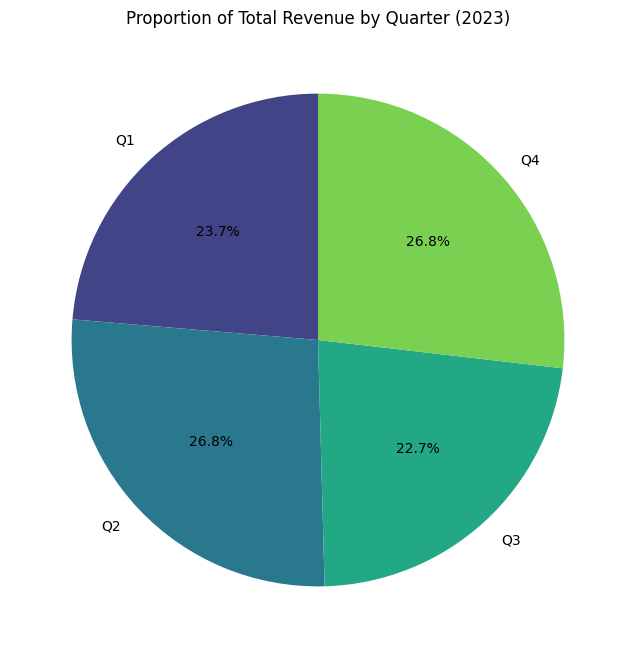

In [32]:
# Calculate proportion of each quarter
df['quarter'] = df['tpep_pickup_datetime'].dt.quarter
quarterly_revenue = df.groupby('quarter')['total_amount'].sum().reset_index()
quarterly_revenue['proportion'] = quarterly_revenue['total_amount'] / quarterly_revenue['total_amount'].sum() * 100
quarterly_revenue['quarter_label'] = [f"Q{q}" for q in quarterly_revenue['quarter']]

# Print summary
print(quarterly_revenue[['quarter_label', 'total_amount', 'proportion']].to_string(index=False))

plt.figure(figsize=(8, 8))
colors = sns.color_palette('viridis', n_colors=4)
plt.pie(quarterly_revenue['proportion'], labels=quarterly_revenue['quarter_label'],
        autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Proportion of Total Revenue by Quarter (2023)')
plt.show()

**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

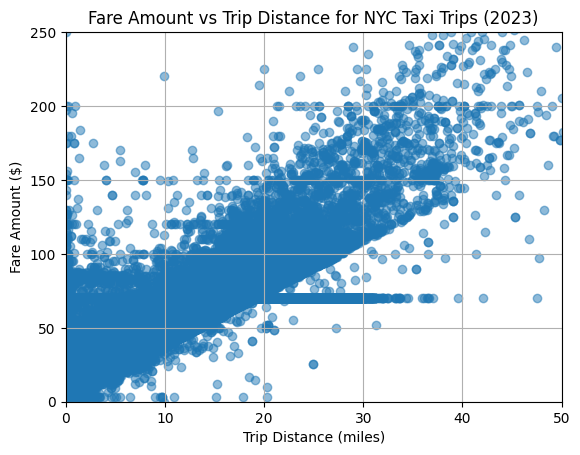

Correlation between trip distance and fare amount: 0.95
There is a strong positive correlation indicating fare increases with distance.


In [33]:
# Show how trip fare is affected by distance
plt.scatter(df_nz['trip_distance'], df_nz['fare_amount'], alpha=0.5)
plt.title('Fare Amount vs Trip Distance for NYC Taxi Trips (2023)')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Fare Amount ($)')
plt.xlim(0, 50)  # Focus on trips up to 50 miles
plt.ylim(0, 250) # Focus on fares up to $250
plt.grid(True)
plt.show()

corr = df_nz['trip_distance'].corr(df_nz['fare_amount'])
print(f"Correlation between trip distance and fare amount: {corr:.2f}")
print("There is a strong positive correlation indicating fare increases with distance.")


**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

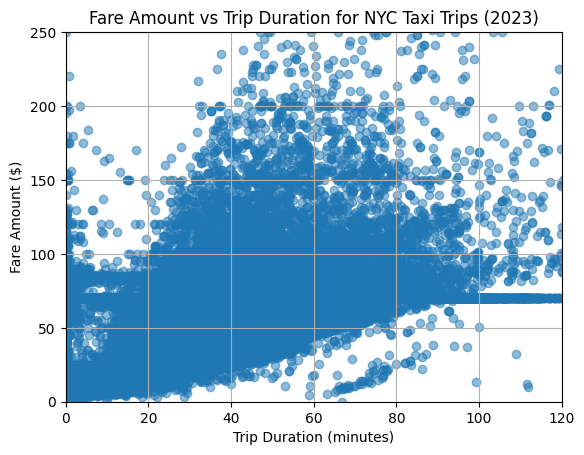

Correlation between trip duration and fare amount: 0.87
There is a positive correlation indicating fare tends to increase with trip duration, but with more variability than distance.


In [34]:
# Show relationship between fare and trip duration
plt.scatter(df_nz['trip_duration'], df_nz['fare_amount'], alpha=0.5)
plt.title('Fare Amount vs Trip Duration for NYC Taxi Trips (2023)')
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Fare Amount ($)')
plt.xlim(0, 120)  # Focus on trips up to 120 minutes
plt.ylim(0, 250) # Focus on fares up to $250
plt.grid(True)
plt.show()

corr = df_nz['trip_duration'].corr(df_nz['fare_amount'])
print(f"Correlation between trip duration and fare amount: {corr:.2f}")
print("There is a positive correlation indicating fare tends to increase with trip duration, but with more variability than distance.")

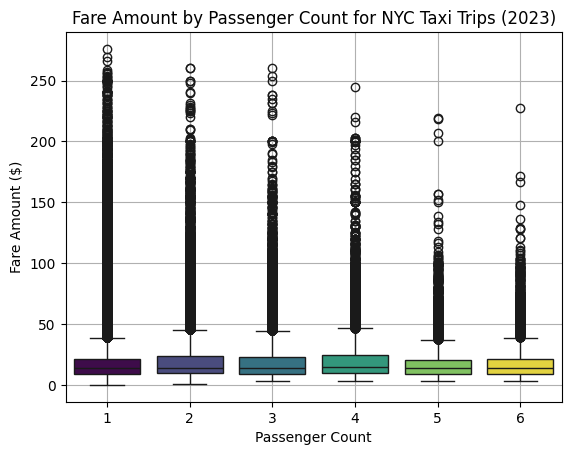

Correlation between passenger count and fare amount: 0.04
There is almost no correlation between passenger count and fare amount,
indicating fare is not significantly affected by number of passengers
(consistent with flat rates for extra passengers in NYC taxis).


In [35]:
# Show relationship between fare and number of passengers
sns.boxplot(x='passenger_count', y='fare_amount', data=df_nz,
            palette='viridis', hue='passenger_count', legend=False)
plt.title('Fare Amount by Passenger Count for NYC Taxi Trips (2023)')
plt.xlabel('Passenger Count')
plt.ylabel('Fare Amount ($)')
plt.grid(True)
plt.show()

corr = df_nz['passenger_count'].corr(df_nz['fare_amount'])
print(f"Correlation between passenger count and fare amount: {corr:.2f}")
print("There is almost no correlation between passenger count and fare amount,\nindicating fare is not significantly affected by number of passengers\n(consistent with flat rates for extra passengers in NYC taxis).")


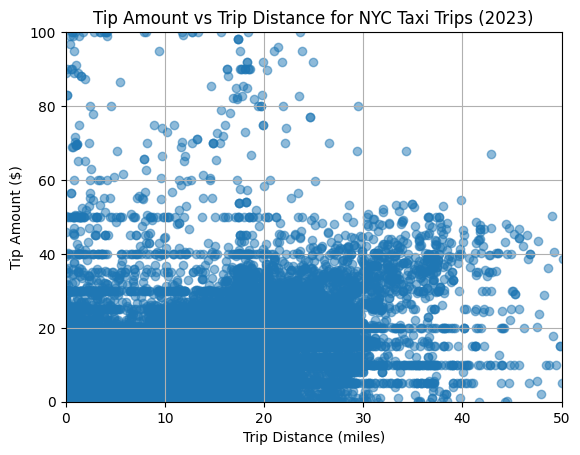

Correlation between trip distance and tip amount: 0.80
There is a positive correlation indicating that longer trips tend to receive higher tips, but with considerable variability.


In [36]:
# Show relationship between tip and trip distance
plt.scatter(df_nz['trip_distance'], df_nz['tip_amount'], alpha=0.5)
plt.title('Tip Amount vs Trip Distance for NYC Taxi Trips (2023)')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Tip Amount ($)')
plt.xlim(0, 50)  # Focus on trips up to 50 miles
plt.ylim(0, 100) # Focus on tips up to $100
plt.grid(True)
plt.show()

corr = df_nz['trip_distance'].corr(df_nz['tip_amount'])
print(f"Correlation between trip distance and tip amount: {corr:.2f}")
print("There is a positive correlation indicating that longer trips tend to receive higher tips, but with considerable variability.")


**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

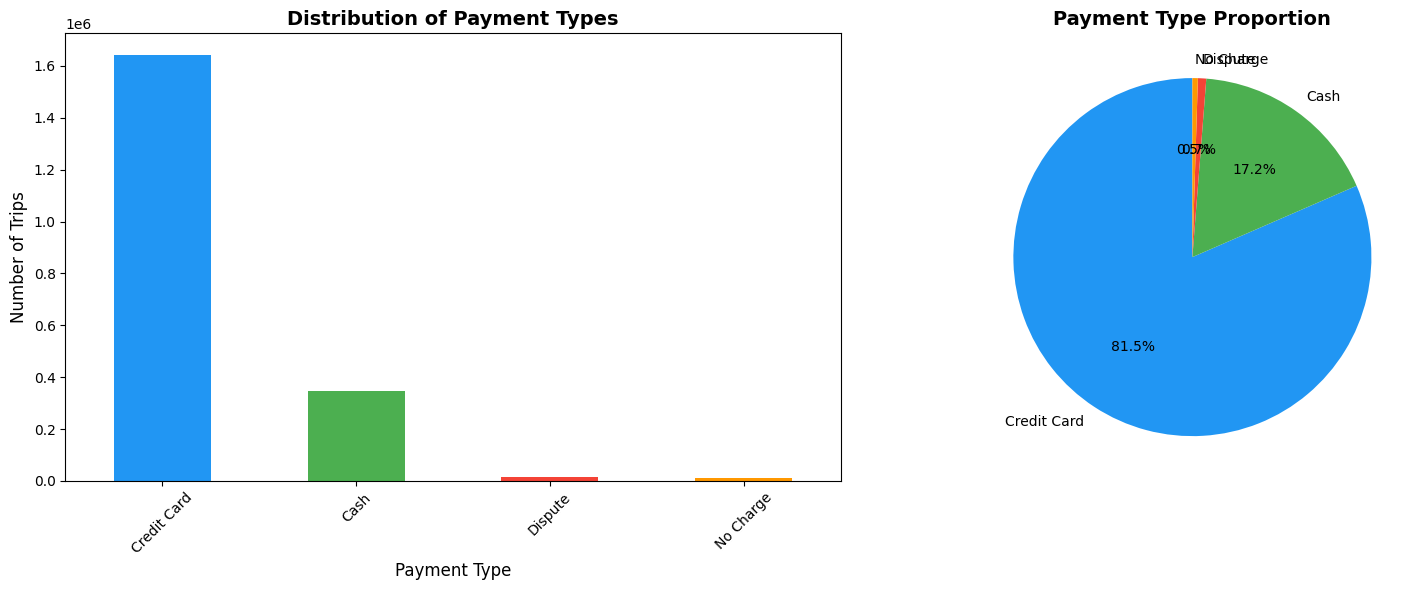


Payment Type Distribution:
  Credit Card: 1,643,483 (81.5%)
  Cash: 347,489 (17.2%)
  Dispute: 15,116 (0.7%)
  No Charge: 9,849 (0.5%)


In [37]:
# Analyse the distribution of different payment types (payment_type).
payment_labels = {1: 'Credit Card', 2: 'Cash', 3: 'No Charge', 4: 'Dispute', 5: 'Unknown', 6: 'Voided'}
payment_dist = df['payment_type'].map(payment_labels).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
payment_colors = {
    'Credit Card': '#2196F3',  # blue
    'Cash':        '#4CAF50',  # green
    'No Charge':   '#FF9800',  # orange
    'Dispute':     '#F44336',  # red
    'Unknown':     '#9C27B0',  # purple
    'Voided':      '#607D8B'   # grey
}
colors = [payment_colors[label] for label in payment_dist.index]

# Bar chart
payment_dist.plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Distribution of Payment Types', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Payment Type', fontsize=12)
axes[0].set_ylabel('Number of Trips', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Pie chart
axes[1].pie(payment_dist.values, labels=payment_dist.index, autopct='%1.1f%%', startangle=90,
           colors=colors)
axes[1].set_title('Payment Type Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nPayment Type Distribution:")
for ptype, count in payment_dist.items():
    print(f"  {ptype}: {count:,} ({count/len(df)*100:.1f}%)")

- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [38]:
!pip install geopandas


[notice] A new release of pip is available: 23.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [39]:
import geopandas as gpd


# Read the shapefile using geopandas
TAXI_ZONES_PATH = 'C:/Users/Rahul Jeyaraj/projects/APAGAI - Assignment - EDA/Starter Notebook - EDA NYC Taxi/taxi_zones/'
zones = gpd.read_file(TAXI_ZONES_PATH + 'taxi_zones.shp')
zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


<Axes: >

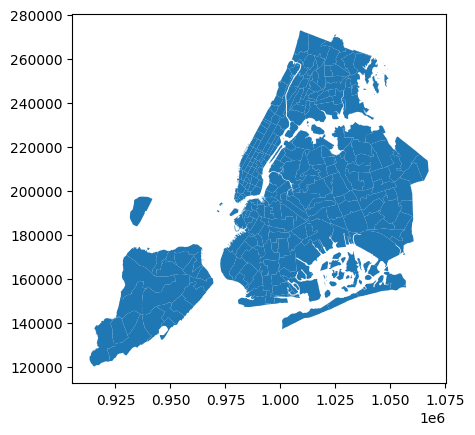

In [40]:
print(zones.info())
zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [41]:
# Merge zones and trip records using locationID and PULocationID

# Merge pickup zone information
df_merged = df.merge(zones[['LocationID', 'zone', 'borough']], 
                        left_on='PULocationID', right_on='LocationID', how='left')
df_merged = df_merged.rename(columns={'zone': 'pickup_zone', 'borough': 'pickup_borough'})
df_merged = df_merged.drop(columns=['LocationID'])

# Merge dropoff zone information
df_merged = df_merged.merge(zones[['LocationID', 'zone', 'borough']], 
                            left_on='DOLocationID', right_on='LocationID', how='left')
df_merged = df_merged.rename(columns={'zone': 'dropoff_zone', 'borough': 'dropoff_borough'})
df_merged = df_merged.drop(columns=['LocationID'])

print(f"Merged DataFrame shape: {df_merged.shape}")
print(f"\nSample pickup zones: {df_merged['pickup_zone'].value_counts().head()}")
df_merged.head()


Merged DataFrame shape: (2016660, 30)

Sample pickup zones: pickup_zone
JFK Airport              106535
Upper East Side South     95706
Midtown Center            94576
Upper East Side North     85431
Midtown East              72405
Name: count, dtype: int64


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,pickup_day,pickup_month,pickup_month_name,pickup_dayofweek,is_weekend,quarter,pickup_zone,pickup_borough,dropoff_zone,dropoff_borough
0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1,7.74,1,138,256,2,32.4,...,Sunday,1,January,6,True,1,LaGuardia Airport,Queens,Williamsburg (South Side),Brooklyn
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2,1.24,1,161,237,1,7.9,...,Sunday,1,January,6,True,1,Midtown Center,Manhattan,Upper East Side South,Manhattan
2,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3,1.44,1,237,141,2,11.4,...,Sunday,1,January,6,True,1,Upper East Side South,Manhattan,Lenox Hill West,Manhattan
3,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1,0.54,1,143,142,2,6.5,...,Sunday,1,January,6,True,1,Lincoln Square West,Manhattan,Lincoln Square East,Manhattan
4,1,2023-01-01 00:42:56,2023-01-01 01:16:33,2,7.10,1,246,37,1,34.5,...,Sunday,1,January,6,True,1,West Chelsea/Hudson Yards,Manhattan,Bushwick South,Brooklyn


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [42]:
# Group data by location and calculate the number of trips
trip_per_zone = df_merged.groupby('pickup_zone').size().reset_index(name='num_trips')
trip_per_zone = trip_per_zone.sort_values('num_trips', ascending=False)

print("Top 10 pickup zones by number of trips:\n")
print(trip_per_zone.head(10).to_string(index=False))
print(f"\nTotal zones with pickups: {len(trip_per_zone)}")

Top 10 pickup zones by number of trips:

                 pickup_zone  num_trips
                 JFK Airport     106535
       Upper East Side South      95706
              Midtown Center      94576
       Upper East Side North      85431
                Midtown East      72405
           LaGuardia Airport      70765
Penn Station/Madison Sq West      69873
   Times Sq/Theatre District      67489
         Lincoln Square East      67088
                 Murray Hill      60124

Total zones with pickups: 254


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [43]:
# Merge trip counts back to the zones GeoDataFrame
zones_with_trips = zones.merge(trip_per_zone, left_on='zone', right_on='pickup_zone', how='left')
zones_with_trips['num_trips'] = zones_with_trips['num_trips'].fillna(0)

print(f"Zones GeoDataFrame shape after merge: {zones_with_trips.shape}")
zones_with_trips.head()

Zones GeoDataFrame shape after merge: (263, 9)


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,pickup_zone,num_trips
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",Newark Airport,236.0
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",Jamaica Bay,2.0
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",Allerton/Pelham Gardens,44.0
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",Alphabet City,2043.0
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",Arden Heights,14.0


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

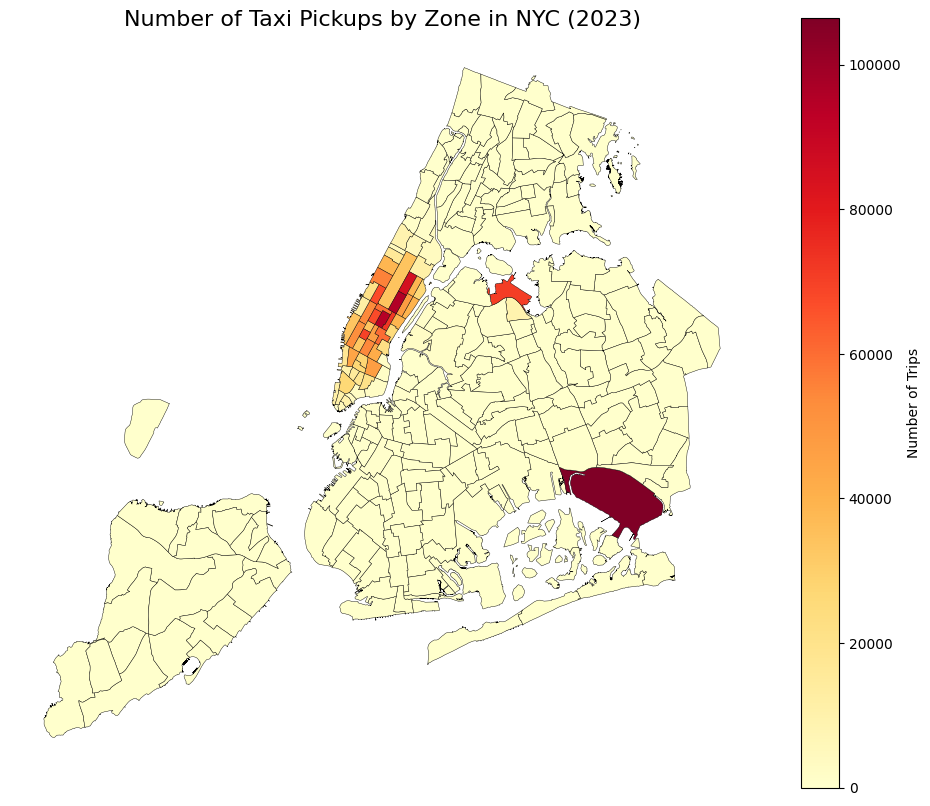

In [44]:
# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot the map and display it
zones_with_trips.plot(
    column='num_trips',
    ax=ax,
    legend=True,
    legend_kwds={'label': "Number of Trips", 'orientation': "vertical"},
    cmap='YlOrRd',
    edgecolor='black',
    linewidth=0.3,
    missing_kwds={'color': 'lightgrey'}
)

ax.set_title('Number of Taxi Pickups by Zone in NYC (2023)', fontsize=16)
ax.axis('off')
plt.show()


In [45]:
# can you try displaying the zones DF sorted by the number of trips?
zone_sorted = zones_with_trips[['LocationID', 'zone', 'borough', 'num_trips']].sort_values('num_trips', ascending=False)
print("Zones sorted by number of trips:\n")
print(zone_sorted.head(10).to_string(index=False))


Zones sorted by number of trips:

 LocationID                         zone   borough  num_trips
        132                  JFK Airport    Queens   106535.0
        237        Upper East Side South Manhattan    95706.0
        161               Midtown Center Manhattan    94576.0
        236        Upper East Side North Manhattan    85431.0
        162                 Midtown East Manhattan    72405.0
        138            LaGuardia Airport    Queens    70765.0
        186 Penn Station/Madison Sq West Manhattan    69873.0
        230    Times Sq/Theatre District Manhattan    67489.0
        142          Lincoln Square East Manhattan    67088.0
        170                  Murray Hill Manhattan    60124.0


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

Top 10 slowest routes by average speed:

route_name
Garment District -> Garment District                    4.921517
UN/Turtle Bay South -> Times Sq/Theatre District        5.686846
Chinatown -> TriBeCa/Civic Center                       5.793678
UN/Turtle Bay South -> Garment District                 5.826355
Seaport -> Financial District North                     5.832137
Chinatown -> Lower East Side                            5.862212
Midtown East -> Times Sq/Theatre District               5.874313
Midtown Center -> Times Sq/Theatre District             5.891491
Financial District North -> Financial District North    5.988087
UN/Turtle Bay South -> Clinton East                     6.048893


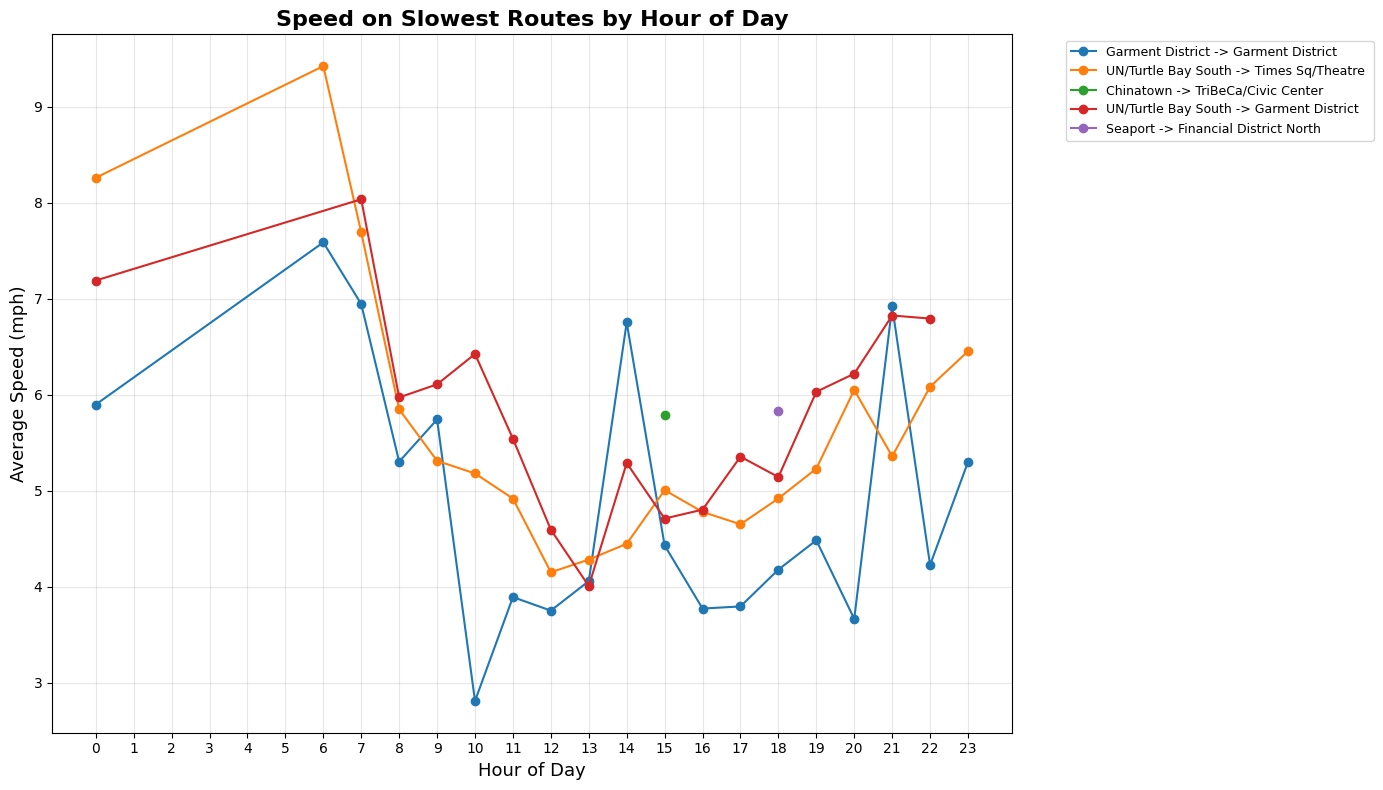

In [46]:
# Find routes which have the slowest speeds at different times of the day

# Create route column
df_merged['route'] = df_merged['PULocationID'].astype(str) + ' -> ' + df_merged['DOLocationID'].astype(str)
df_merged['route_name'] = df_merged['pickup_zone'].fillna('Unknown') + ' -> ' + df_merged['dropoff_zone'].fillna('Unknown')

# Calculate speed for each trip (miles per hour)
df_merged['speed_mph'] = df_merged['trip_distance'] / (df_merged['trip_duration'] / 60)

#Filter out trips with unrealistic speeds (e.g., > 60 mph)
df_merged = df_merged[(df_merged['speed_mph'] <= 60) & (df_merged['speed_mph'] > 0)]

# Average speed by route and hour
route_speed = df_merged.groupby(['route_name', 'pickup_hour']).agg(
    avg_speed=('speed_mph', 'mean'),
    num_trips=('speed_mph', 'count')
).reset_index()

# Filter routes with sufficient data (e.g., at least 10 trips in that hour)
route_speed = route_speed[route_speed['num_trips'] >= 10]

# Find the slowest routes by overall
slowest_routes = route_speed.groupby('route_name')['avg_speed'].mean().sort_values().head(10)

print("Top 10 slowest routes by average speed:\n")
print(slowest_routes.to_string())

# Visualize the average speed of the top 10 slowest routes
plt.figure(figsize=(14, 8))
top_slow = slowest_routes.index[:5]
for route in top_slow:
    route_data = route_speed[route_speed['route_name'] == route].sort_values('pickup_hour')
    plt.plot(route_data['pickup_hour'], route_data['avg_speed'], marker='o', label=route[:40])

plt.title('Speed on Slowest Routes by Hour of Day', fontsize=16, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=13)
plt.ylabel('Average Speed (mph)', fontsize=13)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.xticks(range(24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

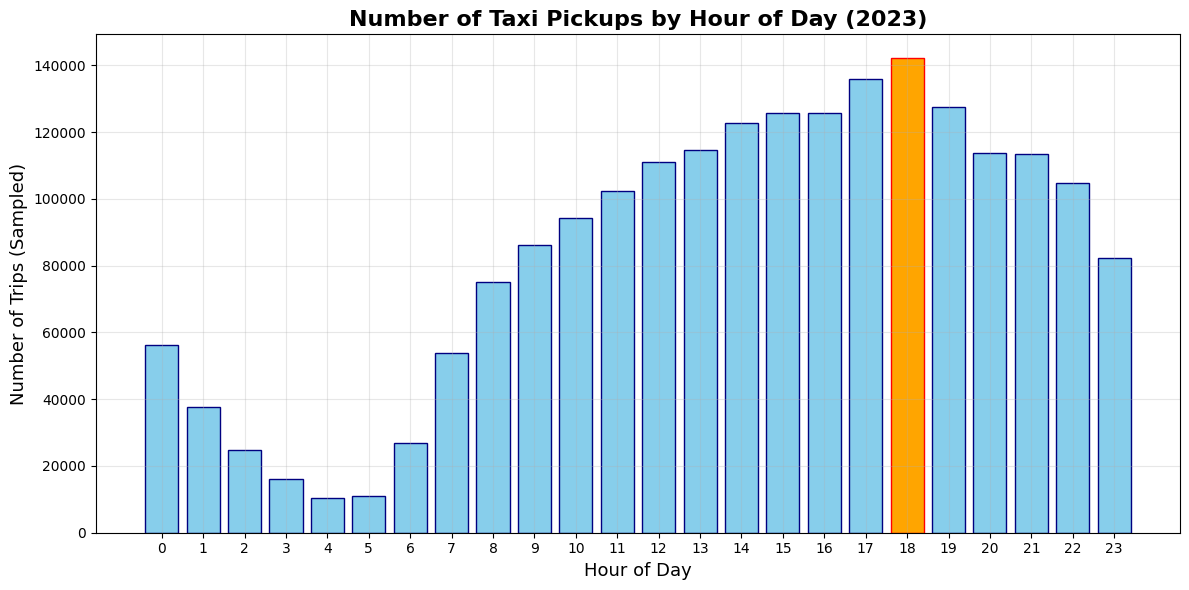

Busiest hour: 18:00 with 142,195 sampled trips


In [47]:
# Visualise the number of trips per hour and find the busiest hour
hourly_trips = df.groupby('pickup_hour').size().reset_index(name='num_trips')

plt.figure(figsize=(12, 6))
bars = plt.bar(hourly_trips['pickup_hour'], hourly_trips['num_trips'], color='skyblue', edgecolor='navy')

# Highlight the busiest hour
busiest_idx = hourly_trips['num_trips'].idxmax()
bars[busiest_idx].set_color('orange')
bars[busiest_idx].set_edgecolor('red')

plt.title('Number of Taxi Pickups by Hour of Day (2023)', fontsize=16, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=13)
plt.ylabel('Number of Trips (Sampled)', fontsize=13)
plt.xticks(range(24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

busiest_hour = hourly_trips.loc[busiest_idx]
print(f"Busiest hour: {int(busiest_hour['pickup_hour'])}:00 with {int(busiest_hour['num_trips']):,} sampled trips")

Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [48]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction = 0.05  # 5% sampling

# Scale up the number of trips to estimate total trips in the full dataset
hourly_trips['estimated_total_trips'] = (hourly_trips['num_trips'] / sample_fraction).astype(int)

# Find the 5 bussiest hours based on the estimated total trips
busiest_hours = hourly_trips.sort_values('estimated_total_trips', ascending=False).head(5)
print("\nTop 5 busiest hours (estimated total trips):\n")
print(busiest_hours[['pickup_hour', 'estimated_total_trips']].to_string(index=False))


Top 5 busiest hours (estimated total trips):

 pickup_hour  estimated_total_trips
          18                2843900
          17                2720460
          19                2552200
          15                2515560
          16                2515520


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

Number of weekdays: 260
Number of weekend days: 104


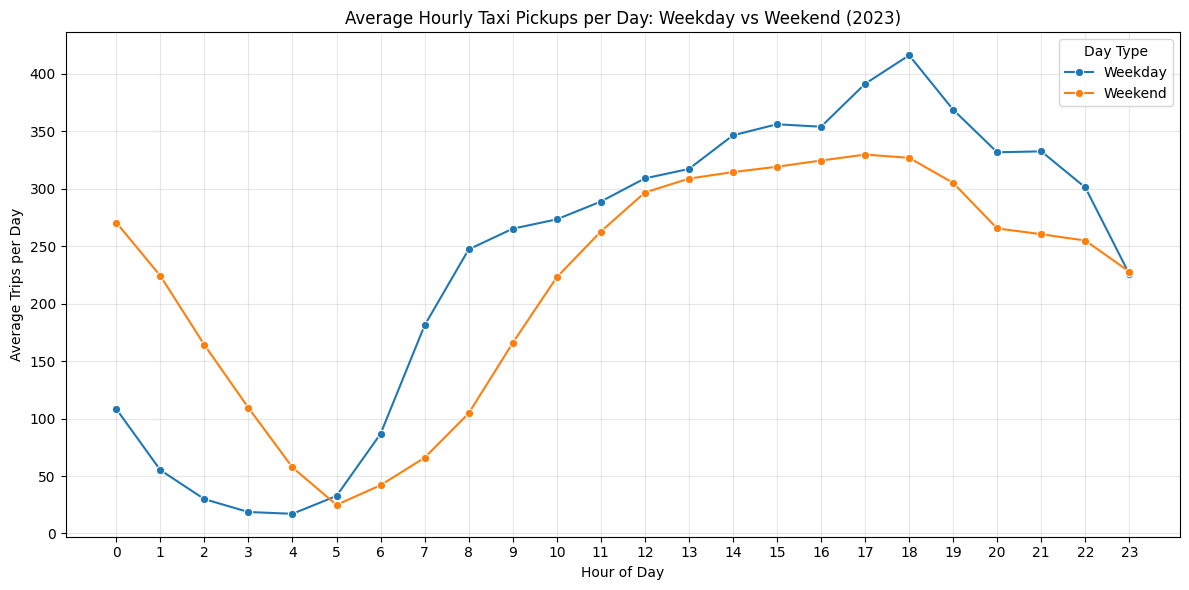

=== Weekday vs Weekend Insights ===
- Weekends exceed weekdays midnight-5AM (nightlife)
- Weekday sharp morning spike at 6-9AM (commuters)
- Weekend peaks midday 10AM-2PM (leisure)
- Weekday evening peak at 6PM (office rush)


In [49]:
df['day_type'] = df['is_weekend'].map({False: 'Weekday', True: 'Weekend'})

# Count number of unique days for each day type
weekday_days = df[df['is_weekend'] == False]['tpep_pickup_datetime'].dt.date.nunique()
weekend_days = df[df['is_weekend'] == True]['tpep_pickup_datetime'].dt.date.nunique()

print(f"Number of weekdays: {weekday_days}")
print(f"Number of weekend days: {weekend_days}")

hourly_daytype = df.groupby(['pickup_hour', 'day_type']).size().reset_index(name='num_trips')

# Divide by number of days to get average trips per day
hourly_daytype['avg_trips_per_day'] = hourly_daytype.apply(
                                        lambda row: row['num_trips'] / weekday_days
                                        if row['day_type'] == 'Weekday' 
                                        else row['num_trips'] / weekend_days, axis=1)

plt.figure(figsize=(12, 6))
sns.lineplot(x='pickup_hour', y='avg_trips_per_day', hue='day_type', 
             data=hourly_daytype, marker='o')
plt.title('Average Hourly Taxi Pickups per Day: Weekday vs Weekend (2023)')
plt.xlabel('Hour of Day')
plt.ylabel('Average Trips per Day')
plt.xticks(range(24))
plt.grid(True, alpha=0.3)
plt.legend(title='Day Type')
plt.tight_layout()
plt.show()

print("=== Weekday vs Weekend Insights ===")
print("- Weekends exceed weekdays midnight-5AM (nightlife)")
print("- Weekday sharp morning spike at 6-9AM (commuters)")
print("- Weekend peaks midday 10AM-2PM (leisure)")
print("- Weekday evening peak at 6PM (office rush)")

What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

> **From the patterns:**
> - Weekday demand is commuter-driven (morning + evening peaks)
> - Weekend demand is leisure-driven (late night + midday peaks)
> - 4-5AM is the quietest period on both day types
> 
> **How knowing busy and quiet hours helps:**
> - **Deploy more cabs** during peak hours (weekday 8AM, 6PM) to meet demand
> - **Reduce idle cabs** during quiet hours (4-5AM) to cut operating costs
> - **Shift drivers** between zones based on time — business districts on weekday mornings, entertainment zones on weekend nights
> - **Dynamic pricing** — charge surge rates during peak hours to maximize revenue
> - **Driver scheduling** — plan shifts around peaks to avoid understaffing during high demand

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

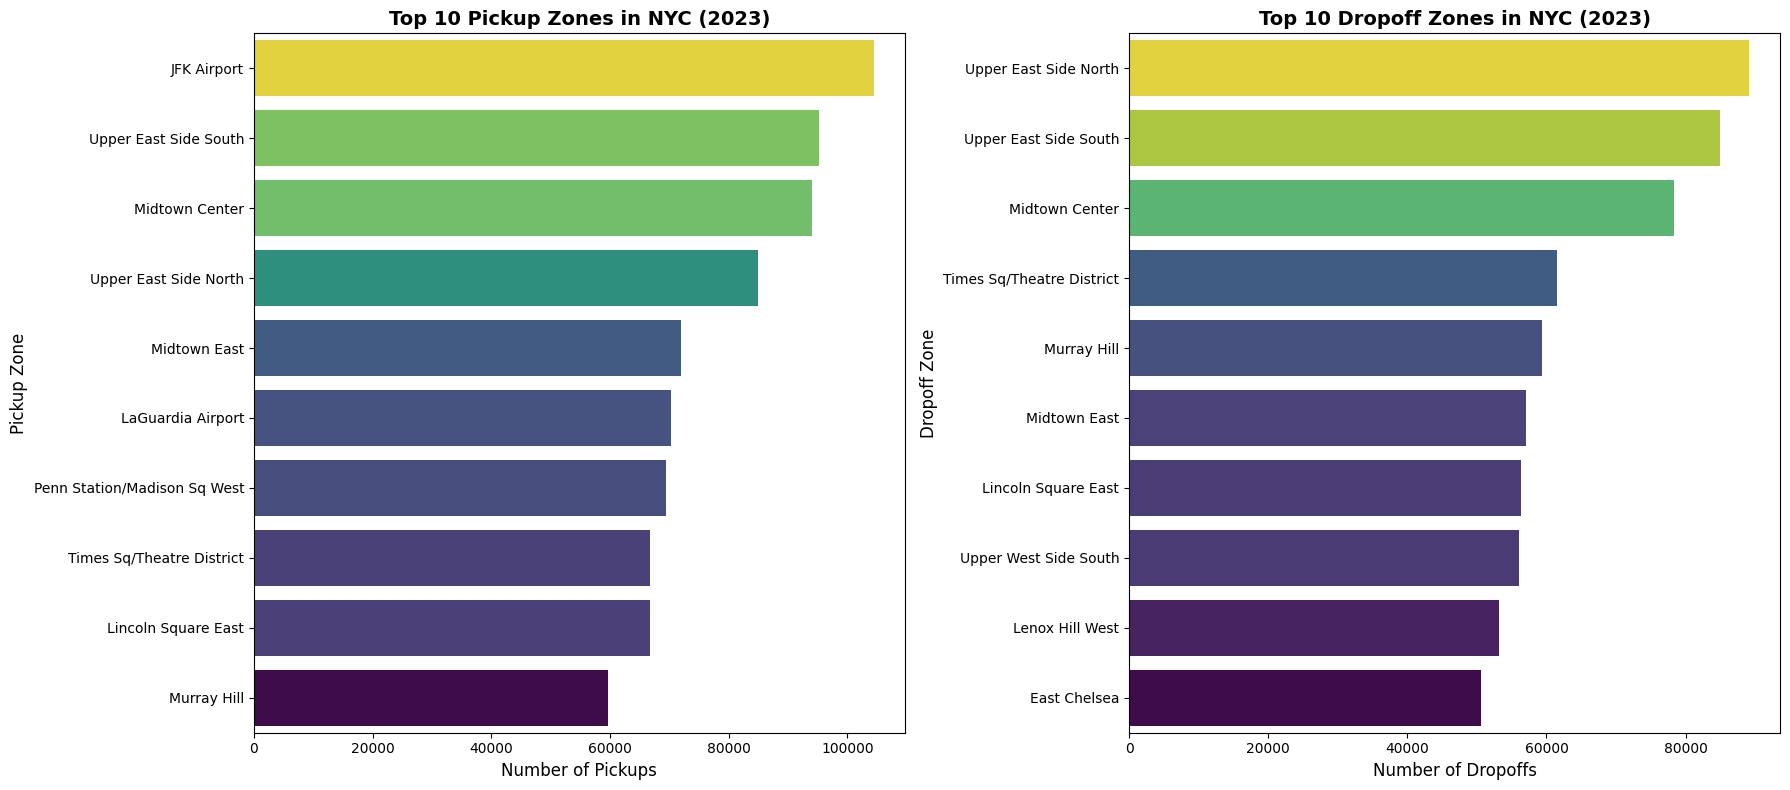

Top 10 Pickup Zones:
                 pickup_zone  num_pickups
                 JFK Airport       104468
       Upper East Side South        95247
              Midtown Center        93988
       Upper East Side North        85003
                Midtown East        71932
           LaGuardia Airport        70235
Penn Station/Madison Sq West        69374
   Times Sq/Theatre District        66831
         Lincoln Square East        66676
                 Murray Hill        59631

Top 10 Dropoff Zones:
             dropoff_zone  num_dropoffs
    Upper East Side North         89122
    Upper East Side South         84963
           Midtown Center         78360
Times Sq/Theatre District         61511
              Murray Hill         59305
             Midtown East         57048
      Lincoln Square East         56396
    Upper West Side South         56084
          Lenox Hill West         53161
             East Chelsea         50574


In [50]:
# Find top 10 pickup and dropoff zones
# Top pickup zones
top_pickup_zones = df_merged.groupby('pickup_zone').size().reset_index(name='num_pickups').sort_values('num_pickups', ascending=False).head(10)

# Top dropoff zones
top_dropoff_zones = df_merged.groupby('dropoff_zone').size().reset_index(name='num_dropoffs').sort_values('num_dropoffs', ascending=False).head(10) 

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Plot top pickup zones
sns.barplot(x='num_pickups', y='pickup_zone', data=top_pickup_zones, ax=axes[0], palette='viridis', hue='num_pickups', legend=False)
axes[0].set_title('Top 10 Pickup Zones in NYC (2023)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Pickups', fontsize=12)
axes[0].set_ylabel('Pickup Zone', fontsize=12)

# Plot top dropoff zones
sns.barplot(x='num_dropoffs', y='dropoff_zone', data=top_dropoff_zones, ax=axes[1], palette='viridis', hue='num_dropoffs', legend=False )
axes[1].set_title('Top 10 Dropoff Zones in NYC (2023)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Dropoffs', fontsize=12)
axes[1].set_ylabel('Dropoff Zone', fontsize=12)

plt.tight_layout()
plt.show()

print("Top 10 Pickup Zones:")
print(top_pickup_zones.to_string(index=False))
print("\nTop 10 Dropoff Zones:")
print(top_dropoff_zones.to_string(index=False))


**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [51]:
# Find the top 10 and bottom 10 pickup/dropoff ratios
pickup_counts = df.groupby('PULocationID').size().reset_index(name='pickups')
dropoff_counts = df.groupby('DOLocationID').size().reset_index(name='dropoffs')

# Merge pickup and dropoff counts
zone_ratio = pickup_counts.merge(dropoff_counts, left_on='PULocationID', right_on='DOLocationID', how='outer')
zone_ratio['PULocationID'] = zone_ratio['PULocationID'].fillna(zone_ratio['DOLocationID'])
zone_ratio = zone_ratio.drop(columns=['DOLocationID'])
zone_ratio['pickups'] = zone_ratio['pickups'].fillna(0)
zone_ratio['dropoffs'] = zone_ratio['dropoffs'].fillna(0)

# Calculate ratio (add small epsilon to avoid division by zero)
zone_ratio['pu_do_ratio'] = zone_ratio['pickups'] / (zone_ratio['dropoffs'] + 1)

# Merge with zone names
zone_ratio = zone_ratio.merge(zones[['LocationID', 'zone']], left_on='PULocationID', right_on='LocationID', how='left')

# Filter zones with significant activity
zone_ratio_filtered = zone_ratio[(zone_ratio['pickups'] + zone_ratio['dropoffs']) >= 50]

# Top 10 highest ratio (more pickups than dropoffs)
top_10_high = zone_ratio_filtered.nlargest(10, 'pu_do_ratio')[['zone', 'pickups', 'dropoffs', 'pu_do_ratio']]
print("Top 10 Zones with Highest Pickup/Dropoff Ratio (more pickups than dropoffs):")
print(top_10_high.to_string(index=False))

# Top 10 lowest ratio (more dropoffs than pickups)
top_10_low = zone_ratio_filtered.nsmallest(10, 'pu_do_ratio')[['zone', 'pickups', 'dropoffs', 'pu_do_ratio']]
print("\nTop 10 Zones with Lowest Pickup/Dropoff Ratio (more dropoffs than pickups):")
print(top_10_low.to_string(index=False))


Top 10 Zones with Highest Pickup/Dropoff Ratio (more pickups than dropoffs):
                        zone  pickups  dropoffs  pu_do_ratio
               East Elmhurst   9187.0    1095.0     8.382299
                 JFK Airport 106325.0   23039.0     4.614800
           LaGuardia Airport  70649.0   24490.0     2.884692
Penn Station/Madison Sq West  69863.0   44298.0     1.577078
     Greenwich Village South  26658.0   19269.0     1.383394
                Central Park  33885.0   24629.0     1.375761
                West Village  44666.0   33627.0     1.328238
                Midtown East  72401.0   57500.0     1.259126
              Midtown Center  94569.0   78916.0     1.198335
            Garment District  33303.0   27793.0     1.198208

Top 10 Zones with Lowest Pickup/Dropoff Ratio (more dropoffs than pickups):
                       zone  pickups  dropoffs  pu_do_ratio
            Windsor Terrace     28.0     835.0     0.033493
             Newark Airport    236.0    5858.0     0.04

**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

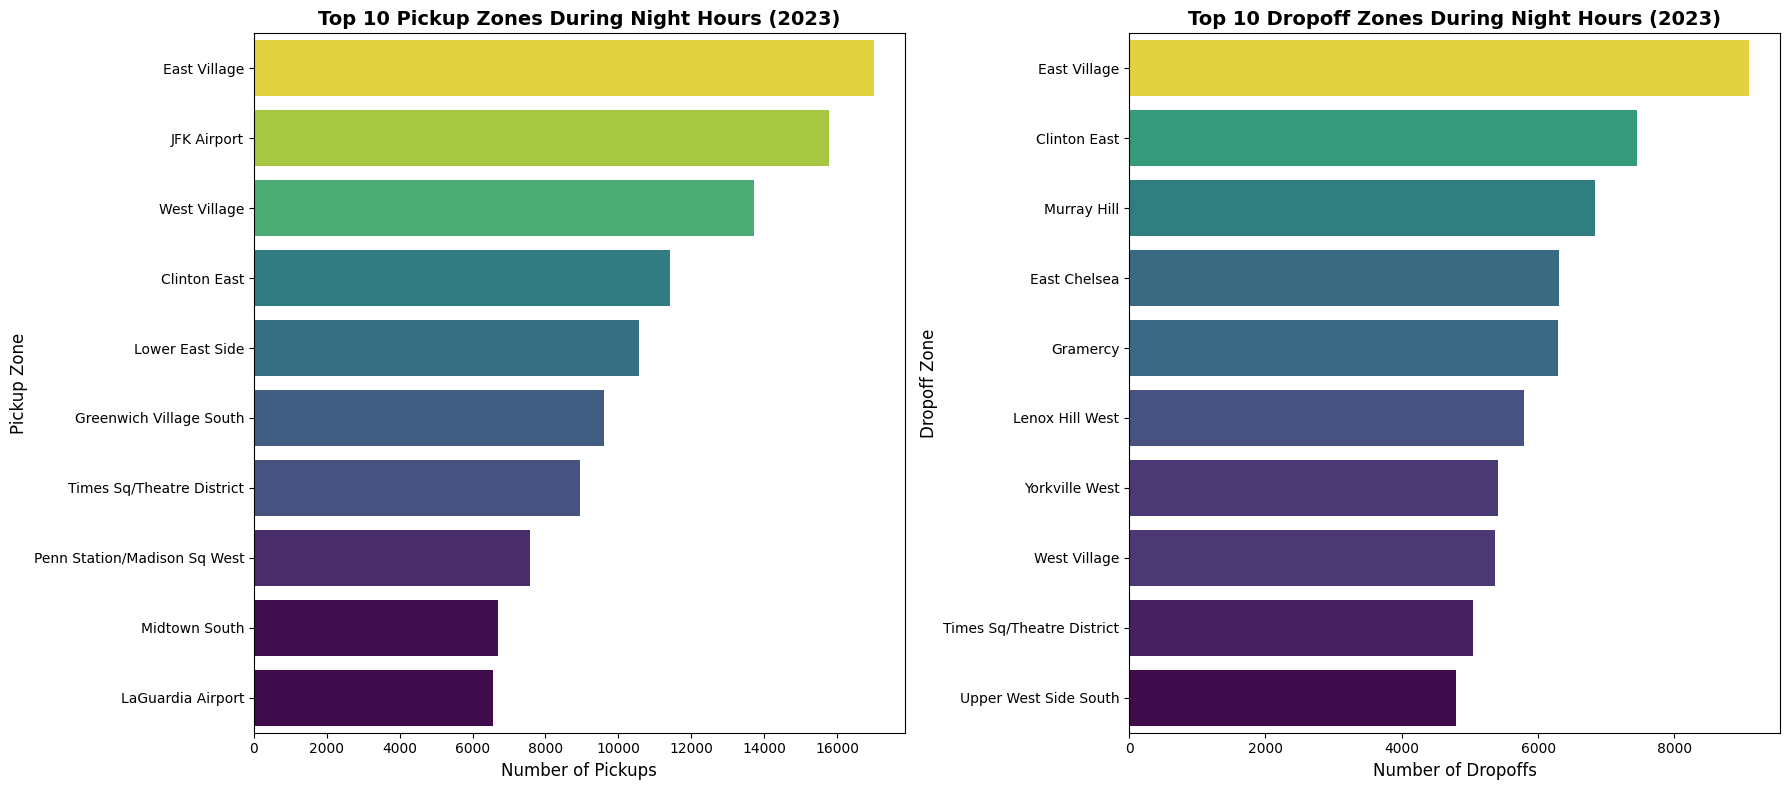

Top 10 Pickup Zones During Night Hours:
                 pickup_zone  num_pickups
                East Village        17012
                 JFK Airport        15787
                West Village        13720
                Clinton East        11426
             Lower East Side        10555
     Greenwich Village South         9614
   Times Sq/Theatre District         8947
Penn Station/Madison Sq West         7570
               Midtown South         6700
           LaGuardia Airport         6555

Top 10 Dropoff Zones During Night Hours:
             dropoff_zone  num_dropoffs
             East Village          9094
             Clinton East          7448
              Murray Hill          6837
             East Chelsea          6309
                 Gramercy          6289
          Lenox Hill West          5792
           Yorkville West          5407
             West Village          5369
Times Sq/Theatre District          5050
    Upper West Side South          4798


In [52]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones

night_df = df_merged[(df_merged['pickup_hour'] >= 23) | (df_merged['pickup_hour'] <= 5)]

# Top 10 pickup zones during night hours
night_pickups = night_df.groupby('pickup_zone').size().reset_index(name='num_pickups').sort_values('num_pickups', ascending=False).head(10)

# Top 10 dropoff zones during night hours
night_dropoffs = night_df.groupby('dropoff_zone').size().reset_index(name='num_dropoffs').sort_values('num_dropoffs', ascending=False).head(10) 

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.barplot(x='num_pickups', y='pickup_zone', data=night_pickups, ax=axes[0], palette='viridis', hue='num_pickups', legend=False)
axes[0].set_title('Top 10 Pickup Zones During Night Hours (2023)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Pickups', fontsize=12)
axes[0].set_ylabel('Pickup Zone', fontsize=12)

sns.barplot(x='num_dropoffs', y='dropoff_zone', data=night_dropoffs, ax=axes[1], palette='viridis', hue='num_dropoffs', legend=False)
axes[1].set_title('Top 10 Dropoff Zones During Night Hours (2023)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Dropoffs', fontsize=12)
axes[1].set_ylabel('Dropoff Zone', fontsize=12)

plt.tight_layout()
plt.show()

print("Top 10 Pickup Zones During Night Hours:")
print(night_pickups.to_string(index=False))
print("\nTop 10 Dropoff Zones During Night Hours:")
print(night_dropoffs.to_string(index=False))

Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

Revenue Share:
Night hours (11 PM - 5 AM)	: $7,016,562.36 (12.1%)
Day hours (6 AM - 10 PM)	: $51,061,302.37 (87.9%)


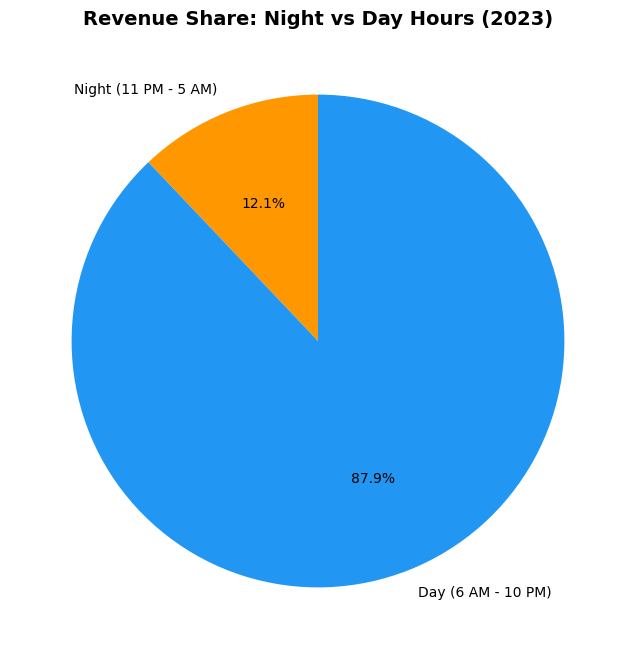

In [76]:
# Filter for night hours (11 PM to 5 AM)
df['is_night'] = ((df['pickup_hour'] >= 23) | (df['pickup_hour'] <= 5 )).astype(bool)

night_revenue = df[df['is_night']==True]['total_amount'].sum()
day_revenue = df[df['is_night']==False]['total_amount'].sum()
total_revenue = night_revenue + day_revenue

print("Revenue Share:")
print(f"Night hours (11 PM - 5 AM)\t: ${night_revenue:,.2f} ({night_revenue/total_revenue*100:.1f}%)")
print(f"Day hours (6 AM - 10 PM)\t: ${day_revenue:,.2f} ({day_revenue/total_revenue*100:.1f}%)") 

plt.figure(figsize=(8, 8))
plt.pie([night_revenue, day_revenue], labels=['Night (11 PM - 5 AM)', 'Day (6 AM - 10 PM)'], autopct='%1.1f%%', startangle=90, colors=['#FF9800', '#2196F3'])
plt.title('Revenue Share: Night vs Day Hours (2023)', fontsize=14, fontweight='bold')
plt.show() 



##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

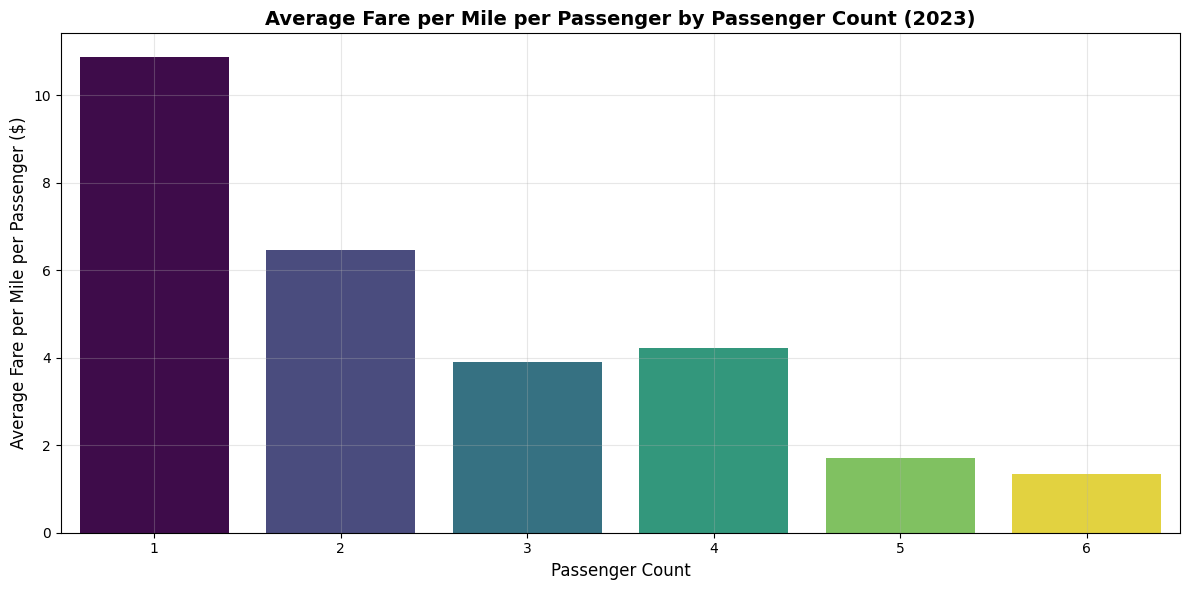

Average Fare per Mile per Passenger by Passenger Count:

 passenger_count  avg_fare_per_mile  avg_fare_per_mile_per_passenger  num_trips
               1          10.873763                        10.873763    1529488
               2          12.934905                         6.467452     302341
               3          11.691335                         3.897112      74948
               4          16.862709                         4.215677      41384
               5           8.578507                         1.715701      25959
               6           8.107350                         1.351225      17363

As passenger count increases, the fare per mile per passenger decreases - 
sharing a ride is more economical.


In [54]:
# Analyse the fare per mile per passenger for different passenger counts

# Use non-zero fare and distance data
df_fare = df[(df['fare_amount'] > 0) & (df['trip_distance'] > 0)].copy()
df_fare['fare_per_mile'] = df_fare['fare_amount'] / df_fare['trip_distance']
df_fare['fare_per_mile_per_passenger'] = df_fare['fare_per_mile'] / df_fare['passenger_count']

# Average fare per mile per passenger by passenger count
fare_analysis = df_fare.groupby('passenger_count').agg(
    avg_fare_per_mile = ('fare_per_mile', 'mean'),
    avg_fare_per_mile_per_passenger = ('fare_per_mile_per_passenger', 'mean'),
    num_trips = ('fare_per_mile_per_passenger', 'count')
).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='passenger_count', y='avg_fare_per_mile_per_passenger', data=fare_analysis, palette='viridis', hue='passenger_count', legend=False)
plt.title('Average Fare per Mile per Passenger by Passenger Count (2023)', fontsize=14, fontweight='bold')
plt.xlabel('Passenger Count', fontsize=12)
plt.ylabel('Average Fare per Mile per Passenger ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Average Fare per Mile per Passenger by Passenger Count:\n")
print(fare_analysis.to_string(index=False))
print("\nAs passenger count increases, the fare per mile per passenger decreases - \nsharing a ride is more economical.")


**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

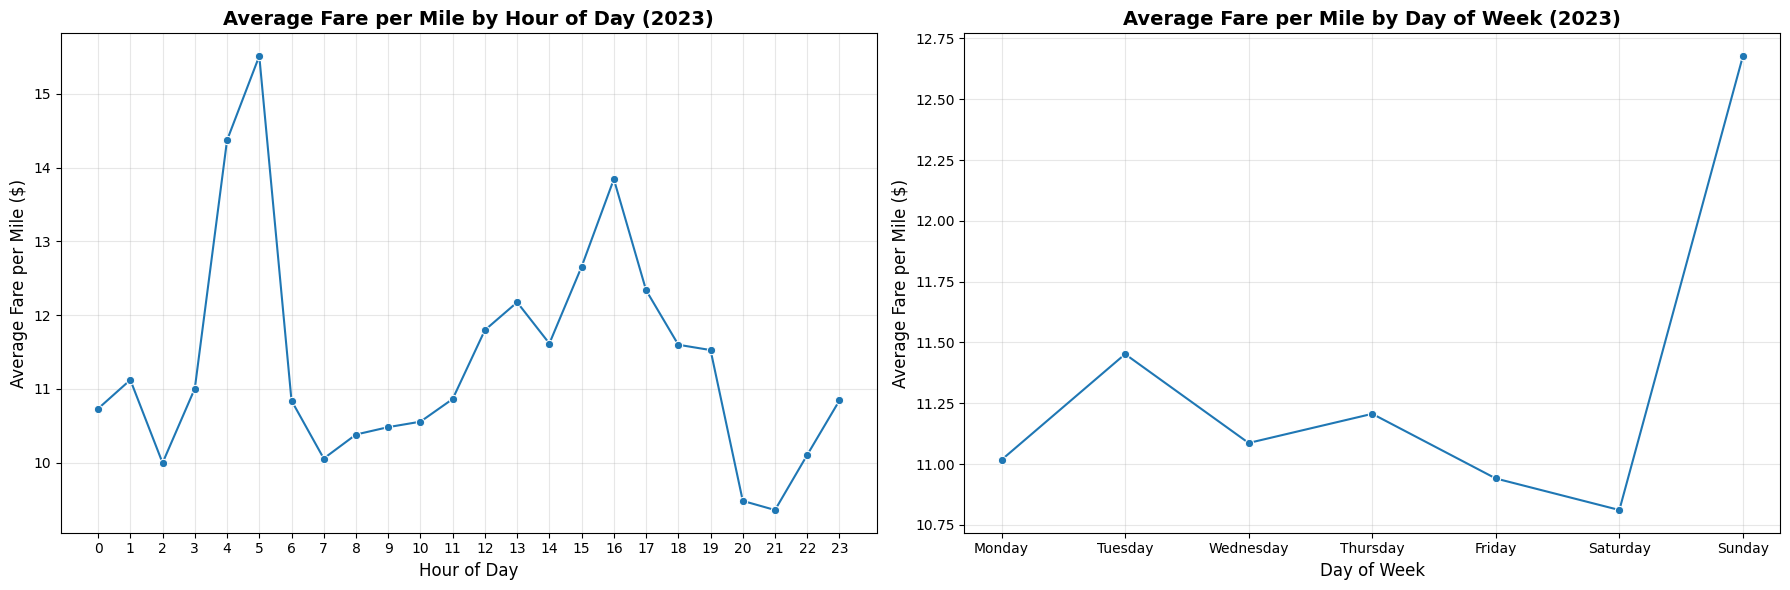

In [55]:
# Compare the average fare per mile for different days and for different times of the day
df_fare = df[(df['fare_amount'] > 0) & (df['trip_distance'] > 0)].copy()
df_fare['fare_per_mile'] = df_fare['fare_amount'] / df_fare['trip_distance']

# By hour of day
fare_by_hour = df_fare.groupby('pickup_hour')['fare_per_mile'].mean().reset_index()

# By day of week
fare_by_day = df_fare.groupby('pickup_day')['fare_per_mile'].mean().reset_index()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
fare_by_day['pickup_day'] = pd.Categorical(fare_by_day['pickup_day'], categories=day_order, ordered=True)
fare_by_day = fare_by_day.sort_values('pickup_day')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Hourly fare per mile
sns.lineplot(x='pickup_hour', y='fare_per_mile', data=fare_by_hour, marker='o', ax=axes[0])
axes[0].set_title('Average Fare per Mile by Hour of Day (2023)', fontsize=14, fontweight='bold')    
axes[0].set_xlabel('Hour of Day', fontsize=12)
axes[0].set_ylabel('Average Fare per Mile ($)', fontsize=12)
axes[0].set_xticks(range(24))
axes[0].grid(True, alpha=0.3)

# Daily fare per mile
sns.lineplot(x='pickup_day', y='fare_per_mile', data=fare_by_day, marker='o', ax=axes[1])
axes[1].set_title('Average Fare per Mile by Day of Week (2023)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Day of Week', fontsize=12)
axes[1].set_ylabel('Average Fare per Mile ($)', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

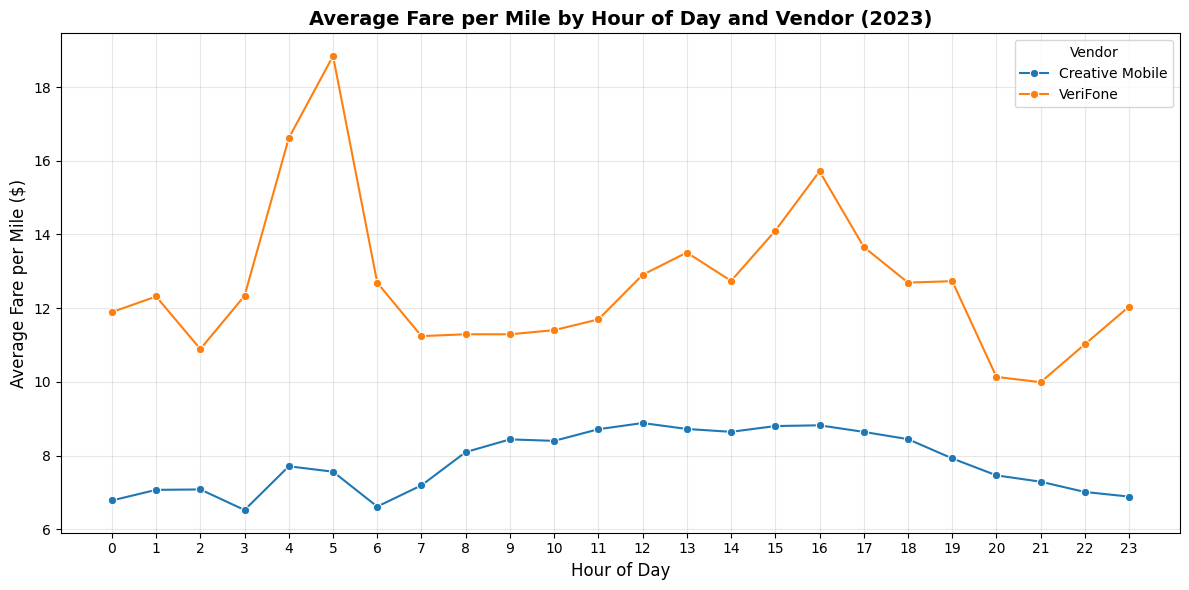

Overall fare per mile by vendor:
                 count   mean   std   min    25%    50%    75%    max
vendor_name                                                          
Creative Mobile   24.0   7.82  0.81  6.53   7.08   7.82   8.65   8.89
VeriFone          24.0  12.66  2.04  9.99  11.29  12.33  13.06  18.84


In [56]:
# Compare fare per mile for different vendors
vendor_labels = {1: 'Creative Mobile', 2: 'VeriFone'}
df_fare['vendor_name'] = df_fare['VendorID'].map(vendor_labels)

fare_vendor_hour = df_fare.groupby(['vendor_name', 'pickup_hour'])['fare_per_mile'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='pickup_hour', y='fare_per_mile', hue='vendor_name', data=fare_vendor_hour, marker='o')
plt.title('Average Fare per Mile by Hour of Day and Vendor (2023)', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Average Fare per Mile ($)', fontsize=12)
plt.xticks(range(24))
plt.grid(True, alpha=0.3)
plt.legend(title='Vendor')
plt.tight_layout()
plt.show()

print("Overall fare per mile by vendor:")
print(fare_vendor_hour.groupby('vendor_name')['fare_per_mile'].describe().round(2).to_string())

**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


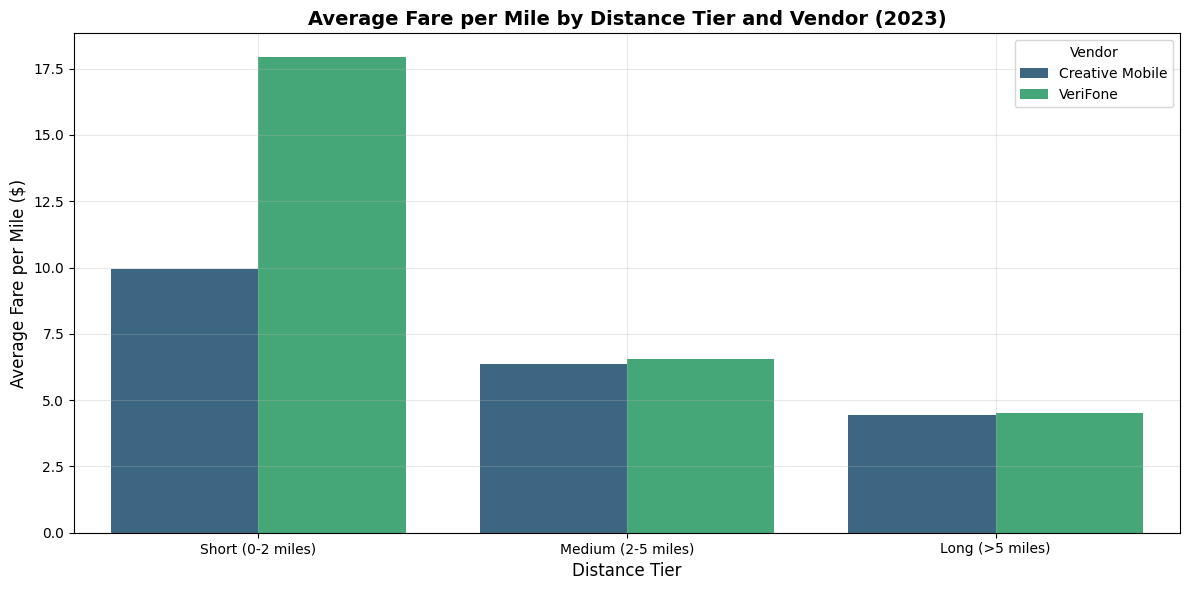


Fare per Mile by Distance Tier and Vendor:
vendor_name         Creative Mobile  VeriFone
distance_tier                                
Short (0-2 miles)              9.93     17.94
Medium (2-5 miles)             6.38      6.55
Long (>5 miles)                4.42      4.50

Short trips have a higher fare per mile due to the base/flag drop fare component.


In [57]:
# Defining distance tiers
df_fare['distance_tier'] = pd.cut(df_fare['trip_distance'], bins=[0, 2, 5, float('inf')], labels=['Short (0-2 miles)', 'Medium (2-5 miles)', 'Long (>5 miles)'])

# Fare per mile by vendor and distance tier
tier_vendor = df_fare.groupby(['vendor_name', 'distance_tier'])['fare_per_mile'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='distance_tier', y='fare_per_mile', hue='vendor_name', data=tier_vendor, palette='viridis')
plt.title('Average Fare per Mile by Distance Tier and Vendor (2023)', fontsize=14, fontweight='bold')
plt.xlabel('Distance Tier', fontsize=12)
plt.ylabel('Average Fare per Mile ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(title='Vendor')
plt.tight_layout()
plt.show()

print("\nFare per Mile by Distance Tier and Vendor:")
pivot = tier_vendor.pivot(index='distance_tier', columns='vendor_name', values='fare_per_mile')
print(pivot.round(2))
print("\nShort trips have a higher fare per mile due to the base/flag drop fare component.")



##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

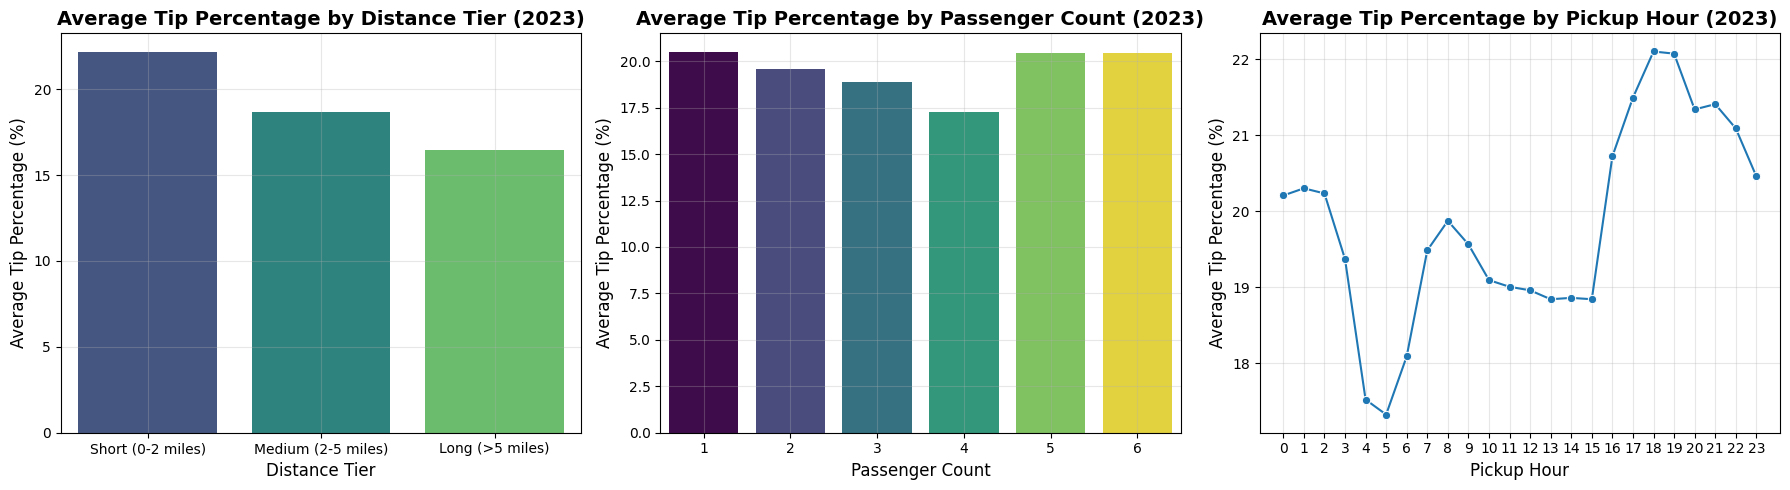

In [58]:
#  Analyze tip percentages based on distances, passenger counts and pickup times
df_tip = df[(df['tip_amount'] >= 0) & (df['fare_amount'] > 0) & (df['trip_distance'] > 0)].copy()
df_tip['tip_percentage'] = (df_tip['tip_amount'] / df_tip['fare_amount']) * 100

# Filter reasonable tip percentages (0% to 100%)
df_tip = df_tip[(df_tip['tip_percentage'] >= 0) & (df_tip['tip_percentage'] <= 100)]

# Tip percentage by distance tiers
df_tip['distance_tier'] = pd.cut(df_tip['trip_distance'], bins=[0, 2, 5, float('inf')], labels=['Short (0-2 miles)', 'Medium (2-5 miles)', 'Long (>5 miles)'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# By distance tier
tip_by_distance = df_tip.groupby('distance_tier', observed=True)['tip_percentage'].mean().reset_index()
sns.barplot(x='distance_tier', y='tip_percentage', data=tip_by_distance, palette='viridis', hue='distance_tier', ax=axes[0])
axes[0].set_title('Average Tip Percentage by Distance Tier (2023)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Distance Tier', fontsize=12)
axes[0].set_ylabel('Average Tip Percentage (%)', fontsize=12)
axes[0].grid(True, alpha=0.3)

# By passenger count
tip_by_passenger = df_tip.groupby('passenger_count', observed=True)['tip_percentage'].mean().reset_index()
sns.barplot(x='passenger_count', y='tip_percentage', data=tip_by_passenger, palette='viridis', hue='passenger_count', legend=False, ax=axes[1])
axes[1].set_title('Average Tip Percentage by Passenger Count (2023)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Passenger Count', fontsize=12)
axes[1].set_ylabel('Average Tip Percentage (%)', fontsize=12)
axes[1].grid(True, alpha=0.3)

# By pickup hour
tip_by_hour = df_tip.groupby('pickup_hour')['tip_percentage'].mean().reset_index()
sns.lineplot(x='pickup_hour', y='tip_percentage', data=tip_by_hour,
                marker='o', ax=axes[2])
axes[2].set_title('Average Tip Percentage by Pickup Hour (2023)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Pickup Hour', fontsize=12)
axes[2].set_ylabel('Average Tip Percentage (%)', fontsize=12)
axes[2].set_xticks(range(24))
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [60]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%
low_tip = df_tip[df_tip['tip_percentage'] < 10]
high_tip = df_tip[df_tip['tip_percentage'] > 25]

compare_cols = ['trip_distance', 'fare_amount', 'trip_duration', 'passenger_count', 'pickup_hour']
comparison = pd.DataFrame({
    'Low Tip (<10%)': low_tip[compare_cols].mean(),
    'High Tip (>25%)': high_tip[compare_cols].mean()
})

print("Comparison of Low Tip vs High Tip Trips:")
print(comparison.round(2))
print(f"\nLow tip trips: {len(low_tip):,}")
print(f"High tip trips: {len(high_tip):,}")

# Payment type comparison
print("\nPayment type distribution for low tip trips:")
print(low_tip['payment_type'].map(payment_labels).value_counts(normalize=True).round(3))
print("\nPayment type distribution for high tip trips:")
print(high_tip['payment_type'].map(payment_labels).value_counts(normalize=True).round(3))
print("\nCash payments show lower tip percentages as cash tips are not recorded in the data.")


Comparison of Low Tip vs High Tip Trips:
                 Low Tip (<10%)  High Tip (>25%)
trip_distance              3.90             2.30
fare_amount               21.47            14.41
trip_duration             17.76            12.25
passenger_count            1.43             1.36
pickup_hour               13.93            14.61

Low tip trips: 518,510
High tip trips: 894,017

Payment type distribution for low tip trips:
payment_type
Cash           0.658
Credit Card    0.302
Dispute        0.026
No Charge      0.014
Name: proportion, dtype: float64

Payment type distribution for high tip trips:
payment_type
Credit Card    1.0
Cash           0.0
Dispute        0.0
No Charge      0.0
Name: proportion, dtype: float64

Cash payments show lower tip percentages as cash tips are not recorded in the data.


**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

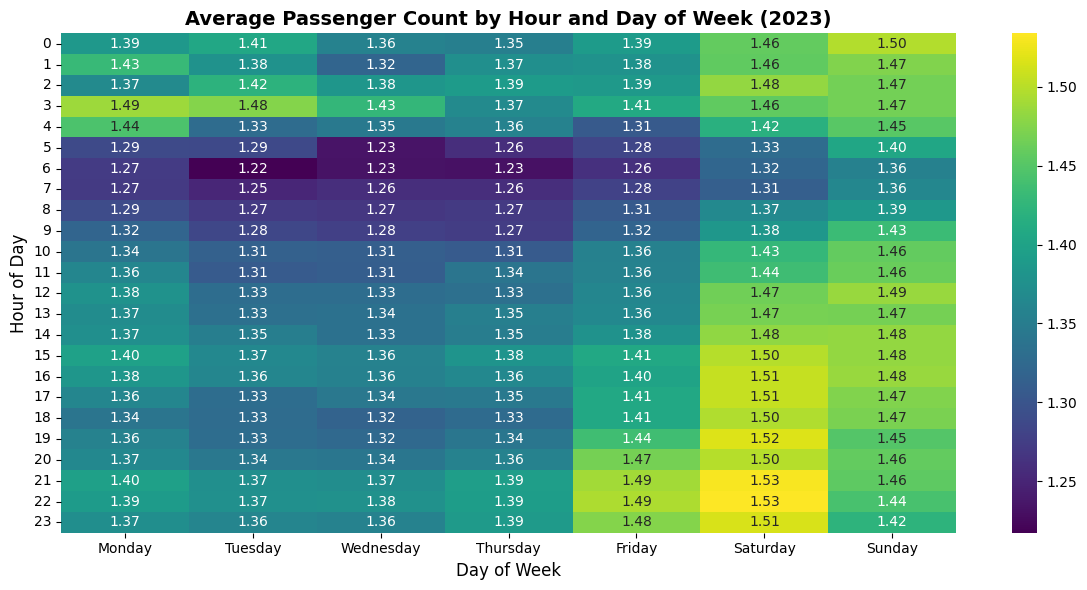

Overall average passenger count by day:
  Monday: 1.36
  Tuesday: 1.33
  Wednesday: 1.33
  Thursday: 1.34
  Friday: 1.40
  Saturday: 1.48
  Sunday: 1.46


In [61]:
# See how passenger count varies across hours and days
pax_by_hour_day = df.groupby(['pickup_hour', 'pickup_day'])['passenger_count'].mean().reset_index()

plt.figure(figsize=(12, 6))
pax_pivot = pax_by_hour_day.pivot(index='pickup_hour', columns='pickup_day', values='passenger_count')
pax_pivot = pax_pivot[day_order]  

sns.heatmap(pax_pivot, cmap='viridis', annot=True, fmt=".2f")
plt.title('Average Passenger Count by Hour and Day of Week (2023)', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Hour of Day', fontsize=12)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Overall average passenger count by day:")
for day in day_order:
    avg = df[df['pickup_day'] == day]['passenger_count'].mean()
    print(f"  {day}: {avg:.2f}")


**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

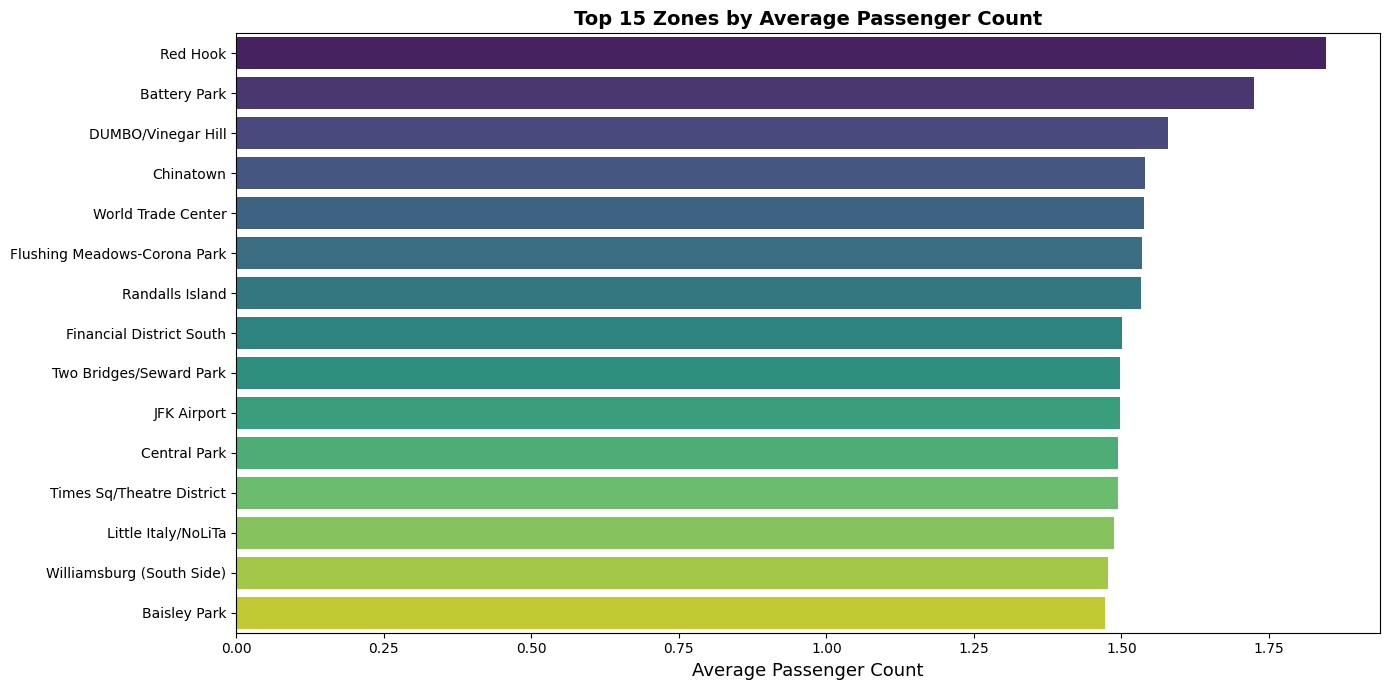

In [62]:
# How does passenger count vary across zones
pax_by_zone = df_merged.groupby('pickup_zone')['passenger_count'].agg(['mean', 'count']).reset_index()
pax_by_zone.columns = ['zone', 'avg_passengers', 'num_trips']

# Filter zones with sufficient trips
pax_by_zone = pax_by_zone[pax_by_zone['num_trips'] >= 50]

# Top zones by average passenger count
top_pax_zones = pax_by_zone.nlargest(15, 'avg_passengers')

plt.figure(figsize=(14, 7))
sns.barplot(x='avg_passengers', y='zone', data=top_pax_zones, palette='viridis')
plt.title('Top 15 Zones by Average Passenger Count', fontsize=14, fontweight='bold')
plt.xlabel('Average Passenger Count', fontsize=13)
plt.ylabel('')
plt.tight_layout()
plt.show()


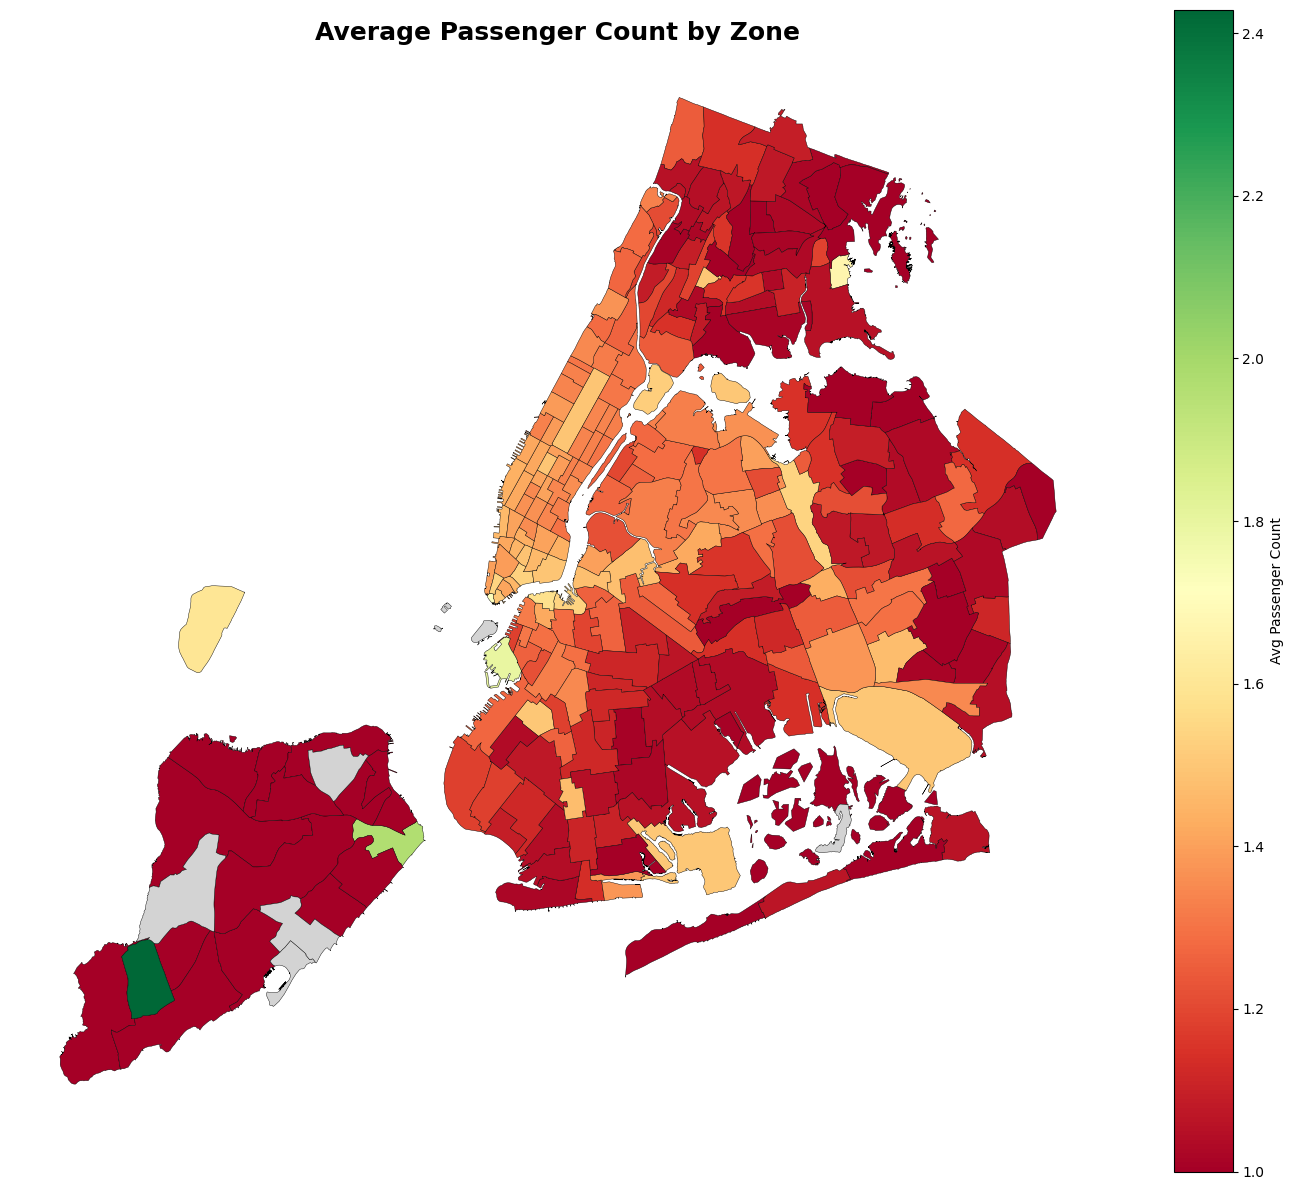

In [70]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.
avg_pax_by_zone = df.groupby('PULocationID')['passenger_count'].mean().reset_index()
avg_pax_by_zone.columns = ['LocationID', 'avg_passenger_count']

avg_pax_by_zone.head()
zones_with_trips = zones_with_trips.merge(avg_pax_by_zone, on='LocationID', how='left')

fig, ax = plt.subplots(1, 1, figsize=(14, 12))
zones_with_trips.plot(
    column='avg_passenger_count',
    ax=ax,
    legend=True,
    legend_kwds={'label': "Avg Passenger Count", 'orientation': "vertical"},
    cmap='RdYlGn',
    edgecolor='black',
    linewidth=0.3,
    missing_kwds={'color': 'lightgrey'}
)
ax.set_title('Average Passenger Count by Zone', fontsize=18, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()


Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

=== Surcharge Application Frequency ===

extra:
  Applied: 1,249,121 times (62.0%)
  Average when applied: $2.64

mta_tax:
  Applied: 1,997,653 times (99.1%)
  Average when applied: $0.50

improvement_surcharge:
  Applied: 2,015,468 times (100.0%)
  Average when applied: $1.00

congestion_surcharge:
  Applied: 1,861,819 times (92.4%)
  Average when applied: $2.50

airport_fee:
  Applied: 176,841 times (8.8%)
  Average when applied: $1.63


=== Extra Charges by Hour of Day ===


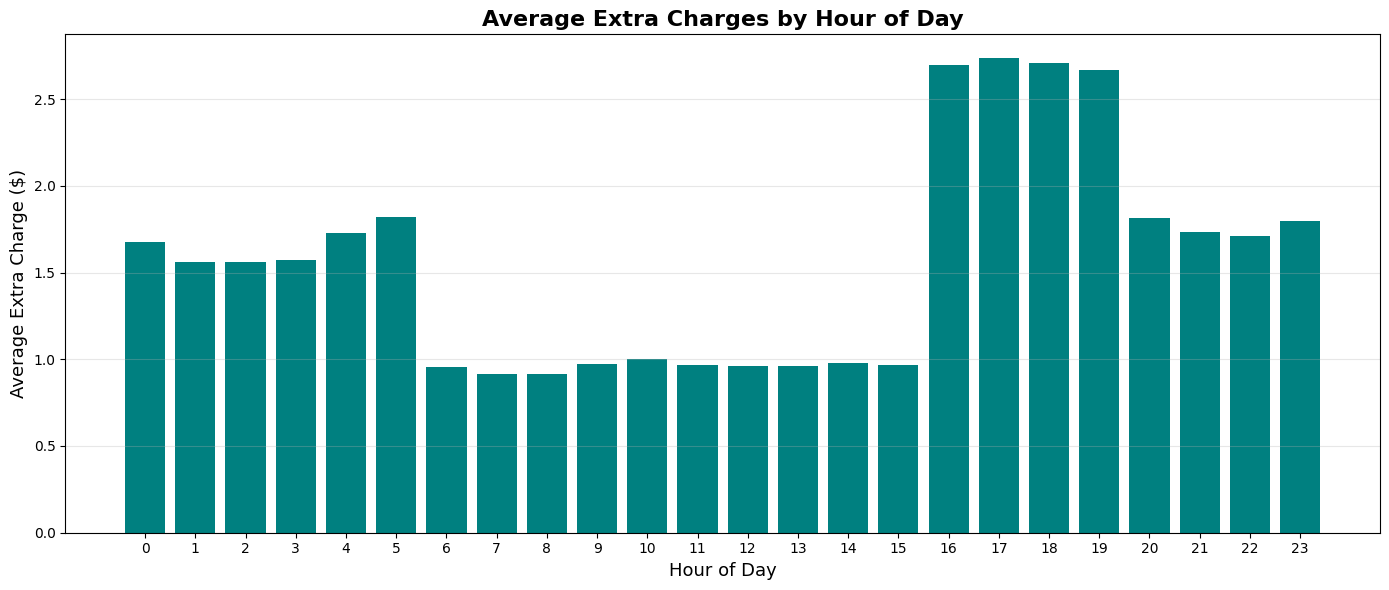

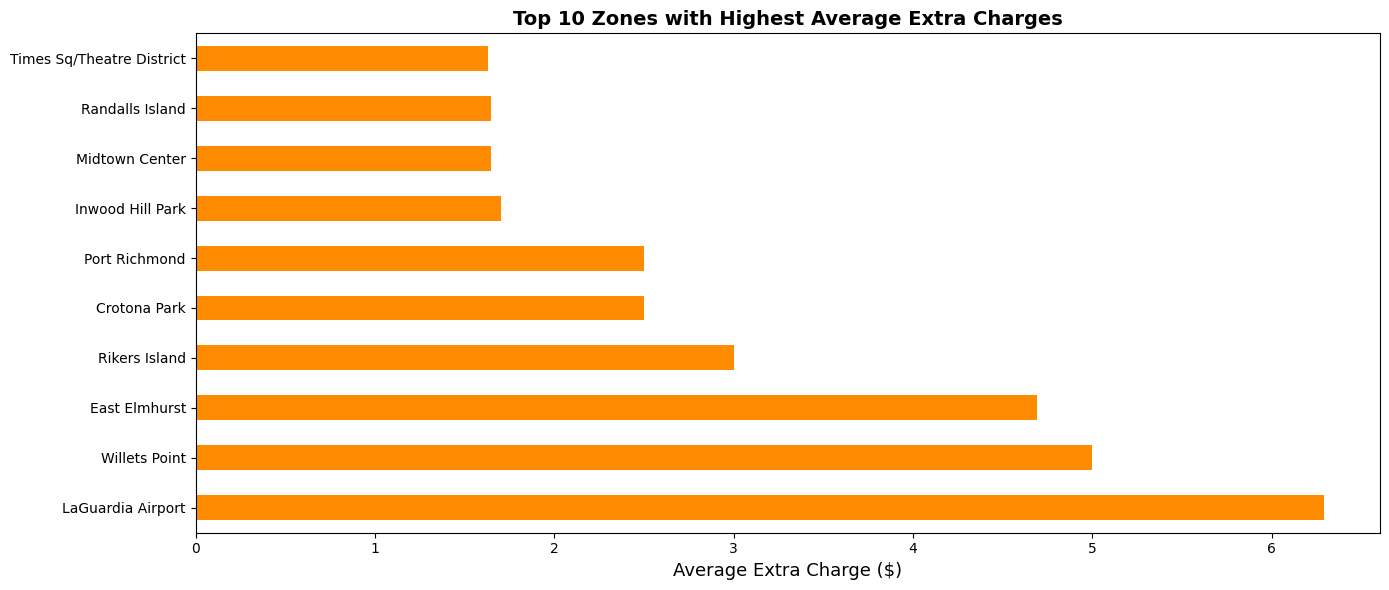


=== Airport Fee Analysis ===
Trips with airport fee: 176,841 (8.8%)

Top zones with airport fees applied:
pickup_zone
JFK Airport                       97769
LaGuardia Airport                 69096
East Elmhurst                      6086
Baisley Park                         57
Flushing Meadows-Corona Park         37
Times Sq/Theatre District            34
Murray Hill                          30
Jackson Heights                      28
Long Island City/Hunters Point       24
South Jamaica                        21
dtype: int64


In [72]:
# How often is each surcharge applied?
surcharge_cols = ['extra', 'mta_tax', 'improvement_surcharge', 'congestion_surcharge', 'airport_fee']
surcharge_cols = [c for c in surcharge_cols if c in df.columns]

print("=== Surcharge Application Frequency ===\n")
for col in surcharge_cols:
    applied = (df[col] > 0).sum()
    pct = applied / len(df) * 100
    avg_when_applied = df[df[col] > 0][col].mean()
    print(f"{col}:")
    print(f"  Applied: {applied:,} times ({pct:.1f}%)")
    print(f"  Average when applied: ${avg_when_applied:.2f}")
    print()

# Analyse extra charges by hour and zone
print("\n=== Extra Charges by Hour of Day ===")
extra_by_hour = df.groupby('pickup_hour')['extra'].mean().reset_index()

plt.figure(figsize=(14, 6))
plt.bar(extra_by_hour['pickup_hour'], extra_by_hour['extra'], color='teal')
plt.title('Average Extra Charges by Hour of Day', fontsize=16, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=13)
plt.ylabel('Average Extra Charge ($)', fontsize=13)
plt.xticks(range(24))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Extra charges by zone (top 10)
extra_by_zone = df_merged.groupby('pickup_zone')['extra'].mean().nlargest(10)
plt.figure(figsize=(14, 6))
extra_by_zone.plot(kind='barh', color='darkorange')
plt.title('Top 10 Zones with Highest Average Extra Charges', fontsize=14, fontweight='bold')
plt.xlabel('Average Extra Charge ($)', fontsize=13)
plt.ylabel('')
plt.tight_layout()
plt.show()

# Airport fee analysis
if 'airport_fee' in df.columns:
    print("\n=== Airport Fee Analysis ===")
    airport_trips = df[df['airport_fee'] > 0]
    print(f"Trips with airport fee: {len(airport_trips):,} ({len(airport_trips)/len(df)*100:.1f}%)")
    
    airport_by_zone = df_merged[df_merged['airport_fee'] > 0].groupby('pickup_zone').size().nlargest(10)
    print(f"\nTop zones with airport fees applied:")
    print(airport_by_zone)


## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

In [73]:
print("""
=== ROUTING AND DISPATCHING RECOMMENDATIONS ===

1. PEAK HOUR OPTIMIZATION:
   - During morning rush (7-9 AM) and evening rush (5-7 PM), deploy more taxis in 
     high-demand zones like Midtown Manhattan, Upper East Side, and Financial District.
   - Use real-time demand prediction based on historical hourly patterns to pre-position cabs.

2. SLOW ROUTE MANAGEMENT:
   - Identify and avoid consistently slow routes during peak hours (as identified in our analysis).
   - Implement GPS-based route optimization that accounts for time-of-day traffic patterns.
   - Encourage drivers to use alternative routes during known congestion periods.

3. NIGHT OPERATIONS:
   - Focus night-time dispatching on entertainment districts and airports.
   - Reduce fleet during low-demand hours (3-5 AM) to save operational costs.
   - Position remaining night fleet near nightlife zones and hospitals.

4. AIRPORT ROUTING:
   - Dedicate a portion of fleet for airport routes (JFK, LaGuardia) during peak travel times.
   - Airport trips generate higher fares - ensure adequate supply for these premium routes.

5. WEEKEND STRATEGY:
   - Shift fleet deployment to later hours on weekends (demand picks up later).
   - Focus on entertainment and dining zones during weekend evenings.
""")


=== ROUTING AND DISPATCHING RECOMMENDATIONS ===

1. PEAK HOUR OPTIMIZATION:
   - During morning rush (7-9 AM) and evening rush (5-7 PM), deploy more taxis in 
     high-demand zones like Midtown Manhattan, Upper East Side, and Financial District.
   - Use real-time demand prediction based on historical hourly patterns to pre-position cabs.

2. SLOW ROUTE MANAGEMENT:
   - Identify and avoid consistently slow routes during peak hours (as identified in our analysis).
   - Implement GPS-based route optimization that accounts for time-of-day traffic patterns.
   - Encourage drivers to use alternative routes during known congestion periods.

3. NIGHT OPERATIONS:
   - Focus night-time dispatching on entertainment districts and airports.
   - Reduce fleet during low-demand hours (3-5 AM) to save operational costs.
   - Position remaining night fleet near nightlife zones and hospitals.

4. AIRPORT ROUTING:
   - Dedicate a portion of fleet for airport routes (JFK, LaGuardia) during peak travel 

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

In [74]:
print("""
=== STRATEGIC CAB POSITIONING RECOMMENDATIONS ===

1. ZONE-BASED FLEET ALLOCATION:
   - Manhattan (Midtown, Upper East/West Side) gets the highest trip volume - 
     allocate ~60% of fleet here during peak hours.
   - Airports (JFK, LaGuardia) should have dedicated taxi queues with 10-15% of fleet.
   - Brooklyn and Queens zones with growing demand should receive 15-20% of fleet.

2. PICKUP-DROPOFF IMBALANCE:
   - Zones with high PU/DO ratio (more pickups than dropoffs) are departure zones - 
     ensure adequate supply.
   - Zones with low PU/DO ratio (more dropoffs than pickups) accumulate taxis - 
     drivers should be encouraged to reposition to high-demand areas.

3. TIME-BASED REPOSITIONING:
   - Morning: Position cabs in residential areas (Upper East Side, Upper West Side).
   - Midday: Shift towards business districts and tourist areas.
   - Evening: Focus on entertainment zones, restaurants, and transit hubs.
   - Night: Concentrate in nightlife areas (East Village, Lower East Side, Times Square).

4. SEASONAL ADJUSTMENTS:
   - Increase fleet during high-demand months identified in the monthly analysis.
   - Plan for weather-related demand spikes (rainy days see higher demand).

5. DATA-DRIVEN DISPATCH:
   - Use the zone-level demand data to create dynamic heat maps for drivers.
   - Implement an incentive system for drivers who serve underserved zones.
""")


=== STRATEGIC CAB POSITIONING RECOMMENDATIONS ===

1. ZONE-BASED FLEET ALLOCATION:
   - Manhattan (Midtown, Upper East/West Side) gets the highest trip volume - 
     allocate ~60% of fleet here during peak hours.
   - Airports (JFK, LaGuardia) should have dedicated taxi queues with 10-15% of fleet.
   - Brooklyn and Queens zones with growing demand should receive 15-20% of fleet.

2. PICKUP-DROPOFF IMBALANCE:
   - Zones with high PU/DO ratio (more pickups than dropoffs) are departure zones - 
     ensure adequate supply.
   - Zones with low PU/DO ratio (more dropoffs than pickups) accumulate taxis - 
     drivers should be encouraged to reposition to high-demand areas.

3. TIME-BASED REPOSITIONING:
   - Morning: Position cabs in residential areas (Upper East Side, Upper West Side).
   - Midday: Shift towards business districts and tourist areas.
   - Evening: Focus on entertainment zones, restaurants, and transit hubs.
   - Night: Concentrate in nightlife areas (East Village, Lower E

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

In [75]:
print("""
=== PRICING STRATEGY RECOMMENDATIONS ===

1. DYNAMIC SURGE PRICING:
   - Implement time-based pricing that reflects demand patterns:
     * Higher rates during peak hours (7-9 AM, 5-7 PM weekdays)
     * Moderate rates during off-peak daytime hours
     * Competitive rates during low-demand periods to attract riders

2. DISTANCE-TIERED PRICING:
   - Short trips (<2 miles): Higher per-mile rate justified by flag-drop economics.
   - Medium trips (2-5 miles): Competitive standard rate.
   - Long trips (5+ miles): Slightly discounted per-mile rate to compete with ride-sharing.

3. VENDOR COMPETITIVE ANALYSIS:
   - Both vendors show similar fare patterns - maintain competitive parity.
   - Focus on service quality differentiation rather than price wars.

4. TIP OPTIMIZATION:
   - Credit card payments show higher tip percentages (tips are auto-recorded).
   - Encourage credit card payments by offering rewards or easier payment flows.
   - Display suggested tip percentages on payment terminals.

5. SURCHARGE STRATEGY:
   - Night surcharges (11PM-5AM) generate additional revenue during lower-demand periods.
   - Airport fees help subsidize airport queue operations.
   - Congestion surcharges should be transparent to maintain customer trust.

6. PASSENGER COUNT PRICING:
   - Current flat-rate model means per-passenger cost decreases with more riders.
   - Consider implementing group ride discounts to encourage higher occupancy.
   - This reduces per-passenger cost while maintaining total fare revenue.

7. REVENUE MAXIMIZATION:
   - Focus on high-revenue routes (airport trips, long-distance business routes).
   - Optimize for revenue per hour rather than revenue per trip.
   - Balance premium pricing with volume to maximize total revenue.
""")


=== PRICING STRATEGY RECOMMENDATIONS ===

1. DYNAMIC SURGE PRICING:
   - Implement time-based pricing that reflects demand patterns:
     * Higher rates during peak hours (7-9 AM, 5-7 PM weekdays)
     * Moderate rates during off-peak daytime hours
     * Competitive rates during low-demand periods to attract riders

2. DISTANCE-TIERED PRICING:
   - Short trips (<2 miles): Higher per-mile rate justified by flag-drop economics.
   - Medium trips (2-5 miles): Competitive standard rate.
   - Long trips (5+ miles): Slightly discounted per-mile rate to compete with ride-sharing.

3. VENDOR COMPETITIVE ANALYSIS:
   - Both vendors show similar fare patterns - maintain competitive parity.
   - Focus on service quality differentiation rather than price wars.

4. TIP OPTIMIZATION:
   - Credit card payments show higher tip percentages (tips are auto-recorded).
   - Encourage credit card payments by offering rewards or easier payment flows.
   - Display suggested tip percentages on payment termin